# 第一次训练与评估 · 原笔记本逐行精读版

本文件保留原 Notebook 的代码顺序、代码文本和原有输出，在每格代码前插入中文解析。原单元格编号指原文件 cells 数组的位置，从 1 开始，包含 Markdown 与空格；它不是执行计数 In[n]。

**本次未执行原代码。已有输出来自原书历史记录。手工构造的小例子会明确标注，不是运行原程序得到的结果。** 静态逐行层解释语法与执行顺序，专项补注解释关键算法、数据形状与可复核的小数据。若遇原书旧接口或实现缺点，会说明而不暗改原始代码。

原文件：`Chapter_3_GettingStarted/BaselineModeling.ipynb`。原书代码 GPL v3；原文及图片 CC BY-SA 4.0。原作者：Yann-Aël Le Borgne、Wissam Siblini、Bertrand Lebichot、Gianluca Bontempi。中文补注为新增教学改编，遵循 CC BY-SA 4.0。

这是一份阅读用副本。运行代码可能下载数据、训练模型或写文件；阅读不要求执行。

(Baseline_FDS)=
# Baseline fraud detection system

This section aims at showing how a simple fraud detection system can be designed in a few steps. We will use the simulated data generated in the previous section, and will rely on a supervised learning approach as described in the section {ref}`ML_For_CCFD_Baseline_Methodology` of the previous chapter. The baseline supervised learning methodology is illustrated in Fig. 1. 

![alt text](images/baseline_ML_workflow_subset.png)
<p style="text-align: center;">
Fig. 1. Baseline supervised learning methodology for credit card fraud detection. The green area highlights the steps that will be implemented in this section.
</p>

For the sake of simplicity, this section will not address the validation part of the baseline supervised learning methodology. The validation part will be covered in Chapter 5. The design of our fraud detection system will consist of three main steps, highlighted in green in Fig. 1:

1. Defining a training set (historical data) and a test set (new data). The training set is the subset of transactions that are used for training the prediction model. The test set is the subset of transactions that are used to assess the performance of the prediction model.
2. Training a prediction model: This step consists in using the training set to find a prediction model able to predict whether a transaction is genuine or fraudulent. We will rely for this task on the Python `sklearn` library, which provides easy-to-use functions to train prediction models. 
3. Assessing the performance of the prediction model: The performance of the prediction model is assessed using the test set (new data). 

We detail each of these steps in the rest of this section. 

## 源码精读 · 原单元格 2

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 准备公共函数与加工后的模拟数据。

**执行前：** 环境需要公共代码和数据文件。

**执行后：** 实际运行会下载并执行公共文件，必要时克隆 transformed 数据仓库。

逐行行为与特征工程开头类似，但数据仓库换成已经加工过特征的版本。`if not exists` 只检查路径存在与否，并没有校验数据版本、字段完整性和文件日期。这格成功也不代表已训练模型；它只是把后续读取和建模需要的工具、文件准备好。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# Initialization: Load shared functions and simulated data 
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Initialization: Load shared functions and simulated data

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 3 行**

```python
# Load shared functions
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Load shared functions

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 4 行**

```python
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是一条 Notebook/IPython 扩展命令，不是普通 Python 表达式。以 ! 开头会调用系统命令；这里可能下载文件或克隆数据仓库，阅读本解析不会执行它。

只有你真正执行该单元格时才发生上述动作；本解析只说明原命令。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 5 行**

```python
%run shared_functions.py
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是一条 Notebook/IPython 扩展命令，不是普通 Python 表达式。%run 会执行外部脚本并引入其定义。

只有你真正执行该单元格时才发生上述动作；本解析只说明原命令。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 7 行**

```python
# Get simulated data from Github repository
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Get simulated data from Github repository

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 8 行**

```python
if not os.path.exists("simulated-data-transformed"):
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

判断条件：对条件取逻辑否定，作用对象是 `os.path.exists('simulated-data-transformed')`。

条件成立才执行相应缩进分支，不成立则转到后续 elif/else 或跳过。

- 求值 `os.path.exists('simulated-data-transformed')`：检查路径是否存在，返回布尔值。传入：位置参数1是 `'simulated-data-transformed'`
- 求值 `not os.path.exists('simulated-data-transformed')`：对条件取逻辑否定，作用对象是 `os.path.exists('simulated-data-transformed')`

- 调用 `os.path.exists` 时的位置参数1：`'simulated-data-transformed'`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。

**第 9 行**

```python
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
```

执行位置：仅在条件 `not os.path.exists('simulated-data-transformed')` 成立的分支中执行

这是一条 Notebook/IPython 扩展命令，不是普通 Python 表达式。以 ! 开头会调用系统命令；这里可能下载文件或克隆数据仓库，阅读本解析不会执行它。

只有你真正执行该单元格时才发生上述动作；本解析只说明原命令。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [1]:
# Initialization: Load shared functions and simulated data 

# Load shared functions
!curl -O https://raw.githubusercontent.com/Fraud-Detection-Handbook/fraud-detection-handbook/main/Chapter_References/shared_functions.py
%run shared_functions.py

# Get simulated data from Github repository
if not os.path.exists("simulated-data-transformed"):
    !git clone https://github.com/Fraud-Detection-Handbook/simulated-data-transformed
        

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 63076  100 63076    0     0    99k      0 --:--:-- --:--:-- --:--:--     0:-- --:--:--   99k


(Baseline_FDS_Training_Test_Sets)=
## Defining the training and test sets

The training set aims at training a prediction model, while the test set aims at evaluating the performance of the prediction model on new data. In a fraud detection context, the transactions of the test set occur chronologically *after* the transactions used for training the model. 

We will use the transactions from the 2018-07-25 to the 2018-07-31 for the training set, and from the 2018-08-08 to the 2018-08-14 for the test set. One week of data will be sufficient to train a first prediction model and to assess its performance. We will later use larger periods for training and testing to evaluate how larger sets can affect the performance results.

It is worth noting that we choose our test set to take place one week after the last transaction of the training set. In a fraud detection context, this period separating the training and test set is referred to as the *delay period* or *feedback delay* {cite}`dal2017credit`. It accounts for the fact that, in a real-world fraud detection system, the label of a transaction (fraudulent or genuine) is only known after a customer complaint, or thanks to the result of a fraud investigation. Therefore, in a realistic scenario, the annotated data available to train a model and start making predictions for a given day are anterior to that day minus the delay period. Setting a delay period of one week is simplistic. It assumes that the labels (fraudulent or genuine) for all transactions are known exactly one week after they occurred. This is not the case in practice, since the delay may be shorter when customers report frauds quickly, or much longer in cases where frauds remain undetected for months. The delay period is in fact a parameter in the assessment of a fraud detection model, which can be tuned during the validation stage (see [Chapter 5](Validation_Strategies)). A one-week delay is, to a first approximation, a reasonable basis: from experience, statistics generally show that most of the feedback becomes available after a one week delay.   

Let us load the transactions from the 2018-07-25 to the 2018-08-14, and plot the number of transactions per day, fraudulent transactions per day, and fraudulent cards per day.


## 源码精读 · 原单元格 4

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 读取基准实验的日期区间。

**执行前：** 有加工后的每日交易文件。

**执行后：** transactions_df 包含供训练、反馈等待和测试使用的交易。

日期从 2018-07-25 到 2018-08-14，覆盖三个相邻的一周区间：训练、延迟、测试。读取一段连续时间并不等于把这整段都用于 fit，训练函数之后还会按边界切分。

`TX_FRAUD.sum()` 是读取范围内的欺诈笔数，不能直接当测试集欺诈率的分子，因为随后还会按时间和已知欺诈客户过滤。先理解“载入总体范围”，再理解“为一次实验选样本”，两步要分开。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# Load data from the 2018-07-25 to the 2018-08-14
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Load data from the 2018-07-25 to the 2018-08-14

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 3 行**

```python
DIR_INPUT='./simulated-data-transformed/data/' 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：字符串 `./simulated-data-transformed/data/`（文字，不是同名变量）。

把结果绑定到 `DIR_INPUT`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

**第 5 行**

```python
BEGIN_DATE = "2018-07-25"
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：字符串 `2018-07-25`（文字，不是同名变量）。

把结果绑定到 `BEGIN_DATE`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

**第 6 行**

```python
END_DATE = "2018-08-14"
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：字符串 `2018-08-14`（文字，不是同名变量）。

把结果绑定到 `END_DATE`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

**第 8 行**

```python
print("Load  files")
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

把结果显示出来；显示本身不等于将结果交给另一个变量。传入：位置参数1是 `'Load  files'`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `print('Load  files')`：把结果显示出来；显示本身不等于将结果交给另一个变量。传入：位置参数1是 `'Load  files'`

- 调用 `print` 时的位置参数1：`'Load  files'`；先求出该表达式再传入

- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

**第 9 行**

```python
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

IPython 的 %time 会执行后面的语句并记录耗时；计时结果取决于运行环境。 先计算右侧：调用 `read_from_files`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `DIR_INPUT`；位置参数2是 `BEGIN_DATE`；位置参数3是 `END_DATE`。

把结果绑定到 `transactions_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)`：调用 `read_from_files`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `DIR_INPUT`；位置参数2是 `BEGIN_DATE`；位置参数3是 `END_DATE`

- 调用 `read_from_files` 时的位置参数1：`DIR_INPUT`；先求出该表达式再传入
- 调用 `read_from_files` 时的位置参数2：`BEGIN_DATE`；先求出该表达式再传入
- 调用 `read_from_files` 时的位置参数3：`END_DATE`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 10 行**

```python
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

把结果显示出来；显示本身不等于将结果交给另一个变量。传入：位置参数1是 `'{0} transactions loaded, containing {1} fraudulent transactions'.format(len(transactions_df), transactions_df.TX_FRAUD.sum())`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `len(transactions_df)`：取得对象长度：列表是元素数，DataFrame通常是行数。传入：位置参数1是 `transactions_df`
- 求值 `transactions_df.TX_FRAUD.sum()`：对指定数据或窗口求和；0/1标签求和可统计欺诈笔数。这里没有显式传入参数
- 求值 `'{0} transactions loaded, containing {1} fraudulent transactions'.format(len(transactions_df), transactions_df.TX_FRAUD.sum())`：把给定值填入格式字符串的占位位置。传入：位置参数1是 `len(transactions_df)`；位置参数2是 `transactions_df.TX_FRAUD.sum()`
- 求值 `print('{0} transactions loaded, containing {1} fraudulent transactions'.format(len(transactions_df), transactions_df.TX_FRAUD.sum()))`：把结果显示出来；显示本身不等于将结果交给另一个变量。传入：位置参数1是 `'{0} transactions loaded, containing {1} fraudulent transactions'.format(len(transactions_df), transactions_df.TX_FRAUD.sum())`

- 调用 `print` 时的位置参数1：`'{0} transactions loaded, containing {1} fraudulent transactions'.format(len(transactions_df), transactions_df.TX_FRAUD.sum())`；先求出该表达式再传入
- 调用 `'{0} transactions loaded, containing {1} fraudulent transactions'.format` 时的位置参数1：`len(transactions_df)`；先求出该表达式再传入
- 调用 `'{0} transactions loaded, containing {1} fraudulent transactions'.format` 时的位置参数2：`transactions_df.TX_FRAUD.sum()`；先求出该表达式再传入
- 调用 `len` 时的位置参数1：`transactions_df`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [2]:
# Load data from the 2018-07-25 to the 2018-08-14

DIR_INPUT='./simulated-data-transformed/data/' 

BEGIN_DATE = "2018-07-25"
END_DATE = "2018-08-14"

print("Load  files")
%time transactions_df=read_from_files(DIR_INPUT, BEGIN_DATE, END_DATE)
print("{0} transactions loaded, containing {1} fraudulent transactions".format(len(transactions_df),transactions_df.TX_FRAUD.sum()))


Load  files
CPU times: user 48.2 ms, sys: 50.9 ms, total: 99.2 ms
Wall time: 149 ms
201295 transactions loaded, containing 1792 fraudulent transactions


## 源码精读 · 原单元格 5

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义并调用按天统计交易、欺诈交易、欺诈客户的函数。

**执行前：** 输入表含日编号、客户编号和 0/1 标签。

**执行后：** 返回 tx_stats，每行变成一天，含计数和根据起点推算的日期。

这格同时包含函数定义和下方真实调用。定义部分准备配方；最后一条赋值才将整张交易表交进去运行。

三条聚合各有不同含义：全表按天对 `CUSTOMER_ID.count()` 计数，严格说是客户编号非缺失值的个数，在本教材编号完整时等于交易记录数；按天对 `TX_FRAUD.sum()` 相加，是欺诈笔数；先筛欺诈行，再按天对客户 `.nunique()`，是受影响客户数。人工一天有 A 的两笔欺诈、B 的一笔正常、C 的一笔欺诈，则三项分别 4、3、2。不是 4、3、3。

`pd.DataFrame({...})` 将三个 Series 按天索引对齐。若某一天没有欺诈行，第三个 Series 可能根本没有那天的索引，拼表时出现缺失；这与明确计算得零要区分。随后 `reset_index()` 把天索引变成列。最后从字符串起点解析日期，再对每个日编号生成 timedelta，加回起点。这里默认数据原始起点为 4 月 1 日，不是读取实验范围的 7 月 25 日；因为 TX_TIME_DAYS 仍是原模拟全程编号。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 3 行**

```python
def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
```

执行位置：此处是函数 `get_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `get_tx_stats(transactions_df, start_date_df='2018-04-01')`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `transactions_df`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `start_date_df` 的默认表达式 `'2018-04-01'`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 5 行**

```python
    #Number of transactions per day
```

执行位置：本行是注释，不执行。所在上下文：此处是函数 `get_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

原作者的说明性注释：Number of transactions per day

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 6 行**

```python
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：统计非缺失记录数量；不要自动等同包含缺失的所有行数。这里没有显式传入参数。

把结果绑定到 `nb_tx_per_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `['TX_TIME_DAYS']`：含 1 项的列表：字符串 `TX_TIME_DAYS`（文字，不是同名变量）
- 求值 `transactions_df.groupby(['TX_TIME_DAYS'])`：按键划分组，先形成分组对象；后面的聚合或 apply 才决定输出。传入：位置参数1是 `['TX_TIME_DAYS']`
- 求值 `transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID']`：从 `transactions_df.groupby(['TX_TIME_DAYS'])` 中按 `'CUSTOMER_ID'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()`：统计非缺失记录数量；不要自动等同包含缺失的所有行数。这里没有显式传入参数

- 调用 `transactions_df.groupby` 时的位置参数1：`['TX_TIME_DAYS']`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 7 行**

```python
    #Number of fraudulent transactions per day
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Number of fraudulent transactions per day

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 8 行**

```python
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：对指定数据或窗口求和；0/1标签求和可统计欺诈笔数。这里没有显式传入参数。

把结果绑定到 `nb_fraudulent_transactions_per_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `['TX_TIME_DAYS']`：含 1 项的列表：字符串 `TX_TIME_DAYS`（文字，不是同名变量）
- 求值 `transactions_df.groupby(['TX_TIME_DAYS'])`：按键划分组，先形成分组对象；后面的聚合或 apply 才决定输出。传入：位置参数1是 `['TX_TIME_DAYS']`
- 求值 `transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD']`：从 `transactions_df.groupby(['TX_TIME_DAYS'])` 中按 `'TX_FRAUD'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()`：对指定数据或窗口求和；0/1标签求和可统计欺诈笔数。这里没有显式传入参数

- 调用 `transactions_df.groupby` 时的位置参数1：`['TX_TIME_DAYS']`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 9 行**

```python
    #Number of compromised cards per day
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Number of compromised cards per day

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 10 行**

```python
    nb_compromised_cards_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：统计不同值的数量，缺失是否计入取决于参数。这里没有显式传入参数。

把结果绑定到 `nb_compromised_cards_per_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `transactions_df['TX_FRAUD']`：从 `transactions_df` 中按 `'TX_FRAUD'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `transactions_df['TX_FRAUD'] == 1`：判断`transactions_df['TX_FRAUD']` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `transactions_df[transactions_df['TX_FRAUD'] == 1]`：从 `transactions_df` 中按 `transactions_df['TX_FRAUD'] == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `['TX_TIME_DAYS']`：含 1 项的列表：字符串 `TX_TIME_DAYS`（文字，不是同名变量）
- 求值 `transactions_df[transactions_df['TX_FRAUD'] == 1].groupby(['TX_TIME_DAYS'])`：按键划分组，先形成分组对象；后面的聚合或 apply 才决定输出。传入：位置参数1是 `['TX_TIME_DAYS']`
- 求值 `transactions_df[transactions_df['TX_FRAUD'] == 1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()`：统计不同值的数量，缺失是否计入取决于参数。这里没有显式传入参数

- 调用 `transactions_df[transactions_df['TX_FRAUD'] == 1].groupby` 时的位置参数1：`['TX_TIME_DAYS']`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 12 行**

```python
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。传入：位置参数1是 `{'nb_tx_per_day': nb_tx_per_day, 'nb_fraudulent_transactions_per_day': nb_fraudulent_transactions_per_day, 'nb_compromised_cards_per_day': nb_compromised_cards_per_day}`。

把结果绑定到 `tx_stats`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `{'nb_tx_per_day': nb_tx_per_day, 'nb_fraudulent_transactions_per_day': nb_fraudulent_transactions_per_day, 'nb_compromised_cards_per_day': nb_compromised_cards_per_day}`：键值字典：键 `'nb_tx_per_day'` 对应 变量 `nb_tx_per_day` 当前引用的值；键 `'nb_fraudulent_transactions_per_day'` 对应 变量 `nb_fraudulent_transactions_per_day` 当前引用的值；键 `'nb_compromised_cards_per_day'` 对应 变量 `nb_compromised_cards_per_day` 当前引用的值
- 求值 `pd.DataFrame({'nb_tx_per_day': nb_tx_per_day, 'nb_fraudulent_transactions_per_day': nb_fraudulent_transactions_per_day, 'nb_compromised_cards_per_day': nb_compromised_cards_per_day})`：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。传入：位置参数1是 `{'nb_tx_per_day': nb_tx_per_day, 'nb_fraudulent_transactions_per_day': nb_fraudulent_transactions_per_day, 'nb_compromised_cards_per_day': nb_compromised_cards_per_day}`

- 调用 `pd.DataFrame` 时的位置参数1：`{'nb_tx_per_day': nb_tx_per_day, 'nb_fraudulent_transactions_per_day': nb_fraudulent_transactions_per_day, 'nb_compromised_cards_per_day': nb_compromised_cards_per_day}`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `pd`：pandas 的导入别名，提供数据表工具

**第 13 行**

```python
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 12 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 12 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 14 行**

```python
                           "nb_compromised_cards_per_day":nb_compromised_cards_per_day})
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 12 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 12 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 16 行**

```python
    tx_stats=tx_stats.reset_index()
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：重置行索引；drop=True 丢弃旧索引，否则旧索引通常转为列。这里没有显式传入参数。

把结果绑定到 `tx_stats`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `tx_stats.reset_index()`：重置行索引；drop=True 丢弃旧索引，否则旧索引通常转为列。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 18 行**

```python
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按格式字符串把文字日期解析为 datetime 对象。传入：位置参数1是 `start_date_df`；位置参数2是 `'%Y-%m-%d'`。

把结果绑定到 `start_date`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `datetime.datetime.strptime(start_date_df, '%Y-%m-%d')`：按格式字符串把文字日期解析为 datetime 对象。传入：位置参数1是 `start_date_df`；位置参数2是 `'%Y-%m-%d'`

- 调用 `datetime.datetime.strptime` 时的位置参数1：`start_date_df`；先求出该表达式再传入
- 调用 `datetime.datetime.strptime` 时的位置参数2：`'%Y-%m-%d'`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 19 行**

```python
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：先计算 `start_date` 与 `tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算。

把结果绑定到 `tx_date`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `tx_stats['TX_TIME_DAYS']`：从 `tx_stats` 中按 `'TX_TIME_DAYS'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)`：将给定函数应用到指定对象的元素、行列或分组；准确粒度由接收对象和 axis 决定。传入：位置参数1是 `datetime.timedelta`
- 求值 `start_date + tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)`：先计算 `start_date` 与 `tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算

- 调用 `tx_stats['TX_TIME_DAYS'].apply` 时的位置参数1：`datetime.timedelta`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 21 行**

```python
    tx_stats['tx_date']=tx_date
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：变量 `tx_date` 当前引用的值。

再把结果写到 `tx_stats['tx_date']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 23 行**

```python
    return tx_stats
```

执行位置：仅在调用 `get_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：变量 `tx_stats` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 25 行**

```python
tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `get_tx_stats`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `transactions_df`；`start_date_df='2018-04-01'` 是具名参数。

把结果绑定到 `tx_stats`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `get_tx_stats(transactions_df, start_date_df='2018-04-01')`：调用 `get_tx_stats`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `transactions_df`；`start_date_df='2018-04-01'` 是具名参数

- 调用 `get_tx_stats` 时的位置参数1：`transactions_df`；先求出该表达式再传入
- 调用 `get_tx_stats` 时的具名参数 `start_date_df` 接收 `'2018-04-01'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [3]:
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_tx_stats(transactions_df, start_date_df="2018-04-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of compromised cards per day
    nb_compromised_cards_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_cards_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats

tx_stats=get_tx_stats(transactions_df, start_date_df="2018-04-01")


## 源码精读 · 原单元格 6

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义图形模板并绘出三个实验时间段与统计曲线。

**执行前：** 有 tx_stats；此格会建立训练起点和各段长度。

**执行后：** 产生 fraud_and_transactions_stats_fig 图对象，训练/延迟/测试边界保存在本会话名称中。

`%%capture` 收集单元格的输出，不阻止里面的代码执行。函数模板负责在轴上添加背景区间、文字和刻度；下方设置日期并真正调用它。

按原参数：训练从 7 月 25 日开始，长度 7 天；随后等待 7 天；测试从 8 月 8 日开始，长度 7 天。图中用日期标注末日，与切分函数中“不含右边界”的实现配合理解。交易总数曲线除以 50 是为了和欺诈数量放在同一张图展示，它没有把训练交易笔数实际缩减为五十分之一。

阅读函数时留意 `start_date_test`：这个名称来自函数外的状态，没有作为该模板的显式参数传入。复制此函数到新环境后若少了外围赋值，不能保证独立调用仍然成功。学会追踪名称来自参数、局部赋值还是外部变量，比死记每个绘图颜色更重要。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
%%capture
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是一条 Notebook/IPython 扩展命令，不是普通 Python 表达式。%%capture 会捕获此单元格后续输出，并不等于不执行代码。

只有你真正执行该单元格时才发生上述动作；本解析只说明原命令。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 3 行**

```python
# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 5 行**

```python
def get_template_tx_stats(ax ,fs,
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `get_template_tx_stats(ax, fs, start_date_training, title='', delta_train=7, delta_delay=7, delta_test=7, ylim=300)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `ax`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `fs`，本签名未给默认值，调用者需按参数规则提供

- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 6 行**

```python
                          start_date_training,
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第5行函数 `get_template_tx_stats` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `start_date_training`，本签名未给默认值，调用者需按参数规则提供

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 7 行**

```python
                          title='',
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第5行函数 `get_template_tx_stats` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `title` 的默认表达式 `''`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 8 行**

```python
                          delta_train=7,
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第5行函数 `get_template_tx_stats` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `delta_train` 的默认表达式 `7`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 9 行**

```python
                          delta_delay=7,
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第5行函数 `get_template_tx_stats` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `delta_delay` 的默认表达式 `7`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 10 行**

```python
                          delta_test=7,
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第5行函数 `get_template_tx_stats` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `delta_test` 的默认表达式 `7`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 11 行**

```python
                          ylim=300):
```

执行位置：此处是函数 `get_template_tx_stats` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第5行函数 `get_template_tx_stats` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `ylim` 的默认表达式 `300`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 13 行**

```python
    ax.set_title(title, fontsize=fs*1.5)
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

设置图标题。传入：位置参数1是 `title`；`fontsize=fs * 1.5` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `fs * 1.5`：先计算 `fs` 与 `1.5`；数值的 * 是相乘，列表或字符串与整数相乘则重复整段序列，数组/Series通常逐元素相乘
- 求值 `ax.set_title(title, fontsize=fs * 1.5)`：设置图标题。传入：位置参数1是 `title`；`fontsize=fs * 1.5` 是具名参数

- 调用 `ax.set_title` 时的位置参数1：`title`；先求出该表达式再传入
- 调用 `ax.set_title` 时的具名参数 `fontsize` 接收 `fs * 1.5`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 14 行**

```python
    ax.set_ylim([0, ylim])
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

设置纵轴显示范围。传入：位置参数1是 `[0, ylim]`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `[0, ylim]`：含 2 项的列表：常量 `0`；变量 `ylim` 当前引用的值
- 求值 `ax.set_ylim([0, ylim])`：设置纵轴显示范围。传入：位置参数1是 `[0, ylim]`

- 调用 `ax.set_ylim` 时的位置参数1：`[0, ylim]`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 16 行**

```python
    ax.set_xlabel('Date', fontsize=fs)
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

设置横轴标题。传入：位置参数1是 `'Date'`；`fontsize=fs` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `ax.set_xlabel('Date', fontsize=fs)`：设置横轴标题。传入：位置参数1是 `'Date'`；`fontsize=fs` 是具名参数

- 调用 `ax.set_xlabel` 时的位置参数1：`'Date'`；先求出该表达式再传入
- 调用 `ax.set_xlabel` 时的具名参数 `fontsize` 接收 `fs`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 17 行**

```python
    ax.set_ylabel('Number', fontsize=fs)
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

设置纵轴标题。传入：位置参数1是 `'Number'`；`fontsize=fs` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `ax.set_ylabel('Number', fontsize=fs)`：设置纵轴标题。传入：位置参数1是 `'Number'`；`fontsize=fs` 是具名参数

- 调用 `ax.set_ylabel` 时的位置参数1：`'Number'`；先求出该表达式再传入
- 调用 `ax.set_ylabel` 时的具名参数 `fontsize` 接收 `fs`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 19 行**

```python
    plt.yticks(fontsize=fs*0.7) 
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `plt.yticks`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`fontsize=fs * 0.7` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `fs * 0.7`：先计算 `fs` 与 `0.7`；数值的 * 是相乘，列表或字符串与整数相乘则重复整段序列，数组/Series通常逐元素相乘
- 求值 `plt.yticks(fontsize=fs * 0.7)`：调用 `plt.yticks`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`fontsize=fs * 0.7` 是具名参数

- 调用 `plt.yticks` 时的具名参数 `fontsize` 接收 `fs * 0.7`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `plt`：Matplotlib 绘图接口的别名

**第 20 行**

```python
    plt.xticks(fontsize=fs*0.7)    
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `plt.xticks`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`fontsize=fs * 0.7` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `fs * 0.7`：先计算 `fs` 与 `0.7`；数值的 * 是相乘，列表或字符串与整数相乘则重复整段序列，数组/Series通常逐元素相乘
- 求值 `plt.xticks(fontsize=fs * 0.7)`：调用 `plt.xticks`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`fontsize=fs * 0.7` 是具名参数

- 调用 `plt.xticks` 时的具名参数 `fontsize` 接收 `fs * 0.7`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `plt`：Matplotlib 绘图接口的别名

**第 22 行**

```python
    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `ax.axvline`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=delta_train)`；位置参数2是 `0`；位置参数3是 `ylim`；`color='black'` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `datetime.timedelta(days=delta_train)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `ax.axvline(start_date_training + datetime.timedelta(days=delta_train), 0, ylim, color='black')`：调用 `ax.axvline`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=delta_train)`；位置参数2是 `0`；位置参数3是 `ylim`；`color='black'` 是具名参数

- 调用 `ax.axvline` 时的位置参数1：`start_date_training + datetime.timedelta(days=delta_train)`；先求出该表达式再传入
- 调用 `ax.axvline` 时的位置参数2：`0`；先求出该表达式再传入
- 调用 `ax.axvline` 时的位置参数3：`ylim`；先求出该表达式再传入
- 调用 `ax.axvline` 时的具名参数 `color` 接收 `'black'`
- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 23 行**

```python
    ax.axvline(start_date_test, 0, ylim, color="black")
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `ax.axvline`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_test`；位置参数2是 `0`；位置参数3是 `ylim`；`color='black'` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `ax.axvline(start_date_test, 0, ylim, color='black')`：调用 `ax.axvline`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_test`；位置参数2是 `0`；位置参数3是 `ylim`；`color='black'` 是具名参数

- 调用 `ax.axvline` 时的位置参数1：`start_date_test`；先求出该表达式再传入
- 调用 `ax.axvline` 时的位置参数2：`0`；先求出该表达式再传入
- 调用 `ax.axvline` 时的位置参数3：`ylim`；先求出该表达式再传入
- 调用 `ax.axvline` 时的具名参数 `color` 接收 `'black'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 25 行**

```python
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `ax.text`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=2)`；位置参数2是 `ylim - 20`；位置参数3是 `'Training period'`；`fontsize=fs` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `datetime.timedelta(days=2)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=2` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=2)`：先计算 `start_date_training` 与 `datetime.timedelta(days=2)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `ylim - 20`：先取得 变量 `ylim` 当前引用的值，再与 常量 `20` 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `ax.text(start_date_training + datetime.timedelta(days=2), ylim - 20, 'Training period', fontsize=fs)`：调用 `ax.text`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=2)`；位置参数2是 `ylim - 20`；位置参数3是 `'Training period'`；`fontsize=fs` 是具名参数

- 调用 `ax.text` 时的位置参数1：`start_date_training + datetime.timedelta(days=2)`；先求出该表达式再传入
- 调用 `ax.text` 时的位置参数2：`ylim - 20`；先求出该表达式再传入
- 调用 `ax.text` 时的位置参数3：`'Training period'`；先求出该表达式再传入
- 调用 `ax.text` 时的具名参数 `fontsize` 接收 `fs`
- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `2`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 26 行**

```python
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `ax.text`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=delta_train + 2)`；位置参数2是 `ylim - 20`；位置参数3是 `'Delay period'`；`fontsize=fs` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `delta_train + 2`：先计算 `delta_train` 与 `2`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `datetime.timedelta(days=delta_train + 2)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train + 2` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train + 2)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train + 2)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `ylim - 20`：先取得 变量 `ylim` 当前引用的值，再与 常量 `20` 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `ax.text(start_date_training + datetime.timedelta(days=delta_train + 2), ylim - 20, 'Delay period', fontsize=fs)`：调用 `ax.text`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=delta_train + 2)`；位置参数2是 `ylim - 20`；位置参数3是 `'Delay period'`；`fontsize=fs` 是具名参数

- 调用 `ax.text` 时的位置参数1：`start_date_training + datetime.timedelta(days=delta_train + 2)`；先求出该表达式再传入
- 调用 `ax.text` 时的位置参数2：`ylim - 20`；先求出该表达式再传入
- 调用 `ax.text` 时的位置参数3：`'Delay period'`；先求出该表达式再传入
- 调用 `ax.text` 时的具名参数 `fontsize` 接收 `fs`
- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train + 2`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 27 行**

```python
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)
```

执行位置：仅在调用 `get_template_tx_stats` 并执行到本行时发生；仅执行 def 不执行这段函数体

调用 `ax.text`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=delta_train + delta_delay + 2)`；位置参数2是 `ylim - 20`；位置参数3是 `'Test period'`；`fontsize=fs` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `delta_train + delta_delay`：先计算 `delta_train` 与 `delta_delay`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `delta_train + delta_delay + 2`：先计算 `delta_train + delta_delay` 与 `2`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `datetime.timedelta(days=delta_train + delta_delay + 2)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train + delta_delay + 2` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train + delta_delay + 2)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train + delta_delay + 2)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `ylim - 20`：先取得 变量 `ylim` 当前引用的值，再与 常量 `20` 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `ax.text(start_date_training + datetime.timedelta(days=delta_train + delta_delay + 2), ylim - 20, 'Test period', fontsize=fs)`：调用 `ax.text`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `start_date_training + datetime.timedelta(days=delta_train + delta_delay + 2)`；位置参数2是 `ylim - 20`；位置参数3是 `'Test period'`；`fontsize=fs` 是具名参数

- 调用 `ax.text` 时的位置参数1：`start_date_training + datetime.timedelta(days=delta_train + delta_delay + 2)`；先求出该表达式再传入
- 调用 `ax.text` 时的位置参数2：`ylim - 20`；先求出该表达式再传入
- 调用 `ax.text` 时的位置参数3：`'Test period'`；先求出该表达式再传入
- 调用 `ax.text` 时的具名参数 `fontsize` 接收 `fs`
- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train + delta_delay + 2`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 30 行**

```python
cmap = plt.get_cmap('jet')
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `plt.get_cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `'jet'`。

把结果绑定到 `cmap`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `plt.get_cmap('jet')`：调用 `plt.get_cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `'jet'`

- 调用 `plt.get_cmap` 时的位置参数1：`'jet'`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

- `plt`：Matplotlib 绘图接口的别名

**第 31 行**

```python
colors={'nb_tx_per_day':cmap(0), 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：键值字典：键 `'nb_tx_per_day'` 对应 调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `0`；键 `'nb_fraudulent_transactions_per_day'` 对应 调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `200`；键 `'nb_compromised_cards_per_day'` 对应 调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `250`。

把结果绑定到 `colors`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `cmap(0)`：调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `0`
- 求值 `cmap(200)`：调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `200`
- 求值 `cmap(250)`：调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `250`
- 求值 `{'nb_tx_per_day': cmap(0), 'nb_fraudulent_transactions_per_day': cmap(200), 'nb_compromised_cards_per_day': cmap(250)}`：键值字典：键 `'nb_tx_per_day'` 对应 调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `0`；键 `'nb_fraudulent_transactions_per_day'` 对应 调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `200`；键 `'nb_compromised_cards_per_day'` 对应 调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `250`

- 调用 `cmap` 时的位置参数1：`0`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 32 行**

```python
        'nb_fraudulent_transactions_per_day':cmap(200), 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 31 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 31 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `cmap(200)`：调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `200`

- 调用 `cmap` 时的位置参数1：`200`；先求出该表达式再传入

- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 33 行**

```python
        'nb_compromised_cards_per_day':cmap(250)}
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 31 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 31 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `cmap(250)`：调用 `cmap`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `250`

- 调用 `cmap` 时的位置参数1：`250`；先求出该表达式再传入

- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 35 行**

```python
fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `plt.subplots`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `1`；位置参数2是 `1`；`figsize=(15, 8)` 是具名参数。

按位置把右侧多个返回值解包给 `(fraud_and_transactions_stats_fig, ax)`；两侧数量必须匹配，星号解包除外。

- 求值 `(15, 8)`：含 2 项的元组：常量 `15`；常量 `8`
- 求值 `plt.subplots(1, 1, figsize=(15, 8))`：调用 `plt.subplots`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `1`；位置参数2是 `1`；`figsize=(15, 8)` 是具名参数

- 调用 `plt.subplots` 时的位置参数1：`1`；先求出该表达式再传入
- 调用 `plt.subplots` 时的位置参数2：`1`；先求出该表达式再传入
- 调用 `plt.subplots` 时的具名参数 `figsize` 接收 `(15, 8)`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `plt`：Matplotlib 绘图接口的别名

**第 37 行**

```python
# Training period
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Training period

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 38 行**

```python
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：按格式字符串把文字日期解析为 datetime 对象。传入：位置参数1是 `'2018-07-25'`；位置参数2是 `'%Y-%m-%d'`。

把结果绑定到 `start_date_training`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `datetime.datetime.strptime('2018-07-25', '%Y-%m-%d')`：按格式字符串把文字日期解析为 datetime 对象。传入：位置参数1是 `'2018-07-25'`；位置参数2是 `'%Y-%m-%d'`

- 调用 `datetime.datetime.strptime` 时的位置参数1：`'2018-07-25'`；先求出该表达式再传入
- 调用 `datetime.datetime.strptime` 时的位置参数2：`'%Y-%m-%d'`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 39 行**

```python
delta_train = delta_delay = delta_test = 7
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：常量 `7`。

把结果绑定到 `delta_train`, `delta_delay`, `delta_test`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

**第 41 行**

```python
end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train - 1)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算。

把结果绑定到 `end_date_training`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `delta_train - 1`：先取得 变量 `delta_train` 当前引用的值，再与 常量 `1` 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `datetime.timedelta(days=delta_train - 1)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train - 1` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train - 1)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train - 1)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算

- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train - 1`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

**第 43 行**

```python
# Test period
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Test period

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 44 行**

```python
start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train + delta_delay)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算。

把结果绑定到 `start_date_test`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `delta_train + delta_delay`：先计算 `delta_train` 与 `delta_delay`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `datetime.timedelta(days=delta_train + delta_delay)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train + delta_delay` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train + delta_delay)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train + delta_delay)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算

- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train + delta_delay`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

**第 45 行**

```python
end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train + delta_delay + delta_test - 1)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算。

把结果绑定到 `end_date_test`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `delta_train + delta_delay`：先计算 `delta_train` 与 `delta_delay`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `delta_train + delta_delay + delta_test`：先计算 `delta_train + delta_delay` 与 `delta_test`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `delta_train + delta_delay + delta_test - 1`：先取得 先计算 `delta_train + delta_delay` 与 `delta_test`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算，再与 常量 `1` 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `datetime.timedelta(days=delta_train + delta_delay + delta_test - 1)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train + delta_delay + delta_test - 1` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train + delta_delay + delta_test - 1)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train + delta_delay + delta_test - 1)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算

- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train + delta_delay + delta_test - 1`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

**第 47 行**

```python
get_template_tx_stats(ax, fs=20,
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

调用 `get_template_tx_stats`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `ax`；`fs=20` 是具名参数；`start_date_training=start_date_training` 是具名参数；`title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day'` 是具名参数；`delta_train=delta_train` 是具名参数；`delta_delay=delta_delay` 是具名参数；`delta_test=delta_test` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `get_template_tx_stats(ax, fs=20, start_date_training=start_date_training, title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day', delta_train=delta_train, delta_delay=delta_delay, delta_test=delta_test)`：调用 `get_template_tx_stats`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `ax`；`fs=20` 是具名参数；`start_date_training=start_date_training` 是具名参数；`title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day'` 是具名参数；`delta_train=delta_train` 是具名参数；`delta_delay=delta_delay` 是具名参数；`delta_test=delta_test` 是具名参数

- 调用 `get_template_tx_stats` 时的位置参数1：`ax`；先求出该表达式再传入
- 调用 `get_template_tx_stats` 时的具名参数 `fs` 接收 `20`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 48 行**

```python
                      start_date_training=start_date_training,
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 47 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 47 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `get_template_tx_stats` 时的具名参数 `start_date_training` 接收 `start_date_training`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 49 行**

```python
                      title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 47 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 47 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `get_template_tx_stats` 时的具名参数 `title` 接收 `'Total transactions, and number of fraudulent transactions \n and number of compromised cards per day'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 50 行**

```python
                      delta_train=delta_train,
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 47 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 47 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `get_template_tx_stats` 时的具名参数 `delta_train` 接收 `delta_train`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 51 行**

```python
                      delta_delay=delta_delay,
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 47 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 47 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `get_template_tx_stats` 时的具名参数 `delta_delay` 接收 `delta_delay`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 52 行**

```python
                      delta_test=delta_test
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 47 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 47 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `get_template_tx_stats` 时的具名参数 `delta_test` 接收 `delta_test`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 53 行**

```python
                     )
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 47 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 47 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 55 行**

```python
ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day']/50, 'b', color=colors['nb_tx_per_day'], label = '# transactions per day (/50)')
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

根据输入向坐标轴加入图形；作图本身不代表数据被重新训练。传入：位置参数1是 `tx_stats['tx_date']`；位置参数2是 `tx_stats['nb_tx_per_day'] / 50`；位置参数3是 `'b'`；`color=colors['nb_tx_per_day']` 是具名参数；`label='# transactions per day (/50)'` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `tx_stats['tx_date']`：从 `tx_stats` 中按 `'tx_date'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `tx_stats['nb_tx_per_day']`：从 `tx_stats` 中按 `'nb_tx_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `tx_stats['nb_tx_per_day'] / 50`：先取得 从 `tx_stats` 中按 `'nb_tx_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则，再与 常量 `50` 做“除以”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `colors['nb_tx_per_day']`：从 `colors` 中按 `'nb_tx_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day'] / 50, 'b', color=colors['nb_tx_per_day'], label='# transactions per day (/50)')`：根据输入向坐标轴加入图形；作图本身不代表数据被重新训练。传入：位置参数1是 `tx_stats['tx_date']`；位置参数2是 `tx_stats['nb_tx_per_day'] / 50`；位置参数3是 `'b'`；`color=colors['nb_tx_per_day']` 是具名参数；`label='# transactions per day (/50)'` 是具名参数

- 调用 `ax.plot` 时的位置参数1：`tx_stats['tx_date']`；先求出该表达式再传入
- 调用 `ax.plot` 时的位置参数2：`tx_stats['nb_tx_per_day'] / 50`；先求出该表达式再传入
- 调用 `ax.plot` 时的位置参数3：`'b'`；先求出该表达式再传入
- 调用 `ax.plot` 时的具名参数 `color` 接收 `colors['nb_tx_per_day']`
- 调用 `ax.plot` 时的具名参数 `label` 接收 `'# transactions per day (/50)'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 56 行**

```python
ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# fraudulent txs per day')
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

根据输入向坐标轴加入图形；作图本身不代表数据被重新训练。传入：位置参数1是 `tx_stats['tx_date']`；位置参数2是 `tx_stats['nb_fraudulent_transactions_per_day']`；位置参数3是 `'b'`；`color=colors['nb_fraudulent_transactions_per_day']` 是具名参数；`label='# fraudulent txs per day'` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `tx_stats['tx_date']`：从 `tx_stats` 中按 `'tx_date'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `tx_stats['nb_fraudulent_transactions_per_day']`：从 `tx_stats` 中按 `'nb_fraudulent_transactions_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `colors['nb_fraudulent_transactions_per_day']`：从 `colors` 中按 `'nb_fraudulent_transactions_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label='# fraudulent txs per day')`：根据输入向坐标轴加入图形；作图本身不代表数据被重新训练。传入：位置参数1是 `tx_stats['tx_date']`；位置参数2是 `tx_stats['nb_fraudulent_transactions_per_day']`；位置参数3是 `'b'`；`color=colors['nb_fraudulent_transactions_per_day']` 是具名参数；`label='# fraudulent txs per day'` 是具名参数

- 调用 `ax.plot` 时的位置参数1：`tx_stats['tx_date']`；先求出该表达式再传入
- 调用 `ax.plot` 时的位置参数2：`tx_stats['nb_fraudulent_transactions_per_day']`；先求出该表达式再传入
- 调用 `ax.plot` 时的位置参数3：`'b'`；先求出该表达式再传入
- 调用 `ax.plot` 时的具名参数 `color` 接收 `colors['nb_fraudulent_transactions_per_day']`
- 调用 `ax.plot` 时的具名参数 `label` 接收 `'# fraudulent txs per day'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 57 行**

```python
ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# compromised cards per day')
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

根据输入向坐标轴加入图形；作图本身不代表数据被重新训练。传入：位置参数1是 `tx_stats['tx_date']`；位置参数2是 `tx_stats['nb_compromised_cards_per_day']`；位置参数3是 `'b'`；`color=colors['nb_compromised_cards_per_day']` 是具名参数；`label='# compromised cards per day'` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `tx_stats['tx_date']`：从 `tx_stats` 中按 `'tx_date'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `tx_stats['nb_compromised_cards_per_day']`：从 `tx_stats` 中按 `'nb_compromised_cards_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `colors['nb_compromised_cards_per_day']`：从 `colors` 中按 `'nb_compromised_cards_per_day'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label='# compromised cards per day')`：根据输入向坐标轴加入图形；作图本身不代表数据被重新训练。传入：位置参数1是 `tx_stats['tx_date']`；位置参数2是 `tx_stats['nb_compromised_cards_per_day']`；位置参数3是 `'b'`；`color=colors['nb_compromised_cards_per_day']` 是具名参数；`label='# compromised cards per day'` 是具名参数

- 调用 `ax.plot` 时的位置参数1：`tx_stats['tx_date']`；先求出该表达式再传入
- 调用 `ax.plot` 时的位置参数2：`tx_stats['nb_compromised_cards_per_day']`；先求出该表达式再传入
- 调用 `ax.plot` 时的位置参数3：`'b'`；先求出该表达式再传入
- 调用 `ax.plot` 时的具名参数 `color` 接收 `colors['nb_compromised_cards_per_day']`
- 调用 `ax.plot` 时的具名参数 `label` 接收 `'# compromised cards per day'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 59 行**

```python
ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

添加或设置图例。传入：`loc='upper left'` 是具名参数；`bbox_to_anchor=(1.05, 1)` 是具名参数；`fontsize=20` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `(1.05, 1)`：含 2 项的元组：常量 `1.05`；常量 `1`
- 求值 `ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=20)`：添加或设置图例。传入：`loc='upper left'` 是具名参数；`bbox_to_anchor=(1.05, 1)` 是具名参数；`fontsize=20` 是具名参数

- 调用 `ax.legend` 时的具名参数 `loc` 接收 `'upper left'`
- 调用 `ax.legend` 时的具名参数 `bbox_to_anchor` 接收 `(1.05, 1)`
- 调用 `ax.legend` 时的具名参数 `fontsize` 接收 `20`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [4]:
%%capture

# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=7,
                          delta_delay=7,
                          delta_test=7,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_test, 0, ylim, color="black")
    
    ax.text(start_date_training+datetime.timedelta(days=2), ylim-20,'Training period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+2), ylim-20,'Delay period', fontsize=fs)
    ax.text(start_date_training+datetime.timedelta(days=delta_train+delta_delay+2), ylim-20,'Test period', fontsize=fs)


cmap = plt.get_cmap('jet')
colors={'nb_tx_per_day':cmap(0), 
        'nb_fraudulent_transactions_per_day':cmap(200), 
        'nb_compromised_cards_per_day':cmap(250)}

fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))

# Training period
start_date_training = datetime.datetime.strptime("2018-07-25", "%Y-%m-%d")
delta_train = delta_delay = delta_test = 7

end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)

# Test period
start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)

get_template_tx_stats(ax, fs=20,
                      start_date_training=start_date_training,
                      title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day',
                      delta_train=delta_train,
                      delta_delay=delta_delay,
                      delta_test=delta_test
                     )

ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day']/50, 'b', color=colors['nb_tx_per_day'], label = '# transactions per day (/50)')
ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# fraudulent txs per day')
ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# compromised cards per day')

ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)



## 源码精读 · 原单元格 7

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 显示上一格创建的图对象。

**执行前：** 图对象已经创建。

**执行后：** 展示历史上或当前会话中已有的图，不再切分数据。

这一行只有一个变量名。Jupyter 会尝试展示它的富显示表示。不能因为屏幕此刻才出现图片，就推断所有绘图计算都是本行完成的；上一格已运行绘图并通过 capture 隐藏即时输出。这是理解 Notebook 状态与单元格显示之间关系的一个例子。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
fraud_and_transactions_stats_fig
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

变量 `fraud_and_transactions_stats_fig` 当前引用的值。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

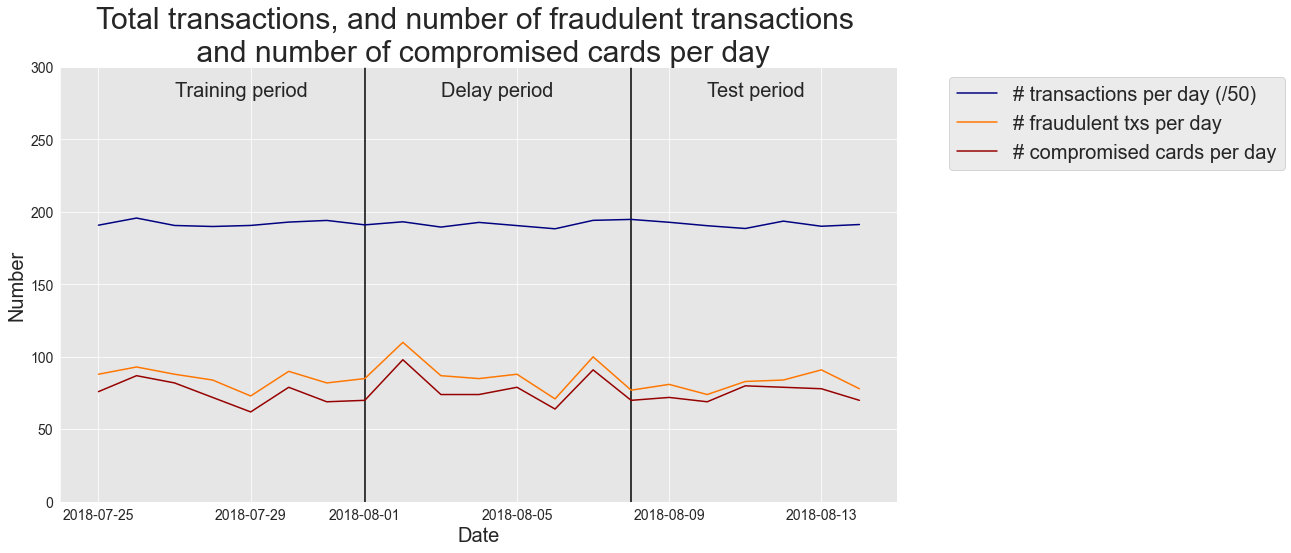

In [5]:
fraud_and_transactions_stats_fig

The plot illustrates that the number of transactions and frauds is similar in the training and test periods. The average number of frauds is around 85 per day. Let us extract from the dataset the transactions for the training set and the test set. 

## 源码精读 · 原单元格 9

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义按时间和已知欺诈客户状态构造训练集、测试集的函数。

**执行前：** 有连续交易表、训练起点、训练/延迟/测试天数。

**执行后：** 调用返回 (train_df, test_df)，测试部分逐日剔除当时已知欺诈客户。

先读训练边界：`时间>=训练起点` 与 `时间<训练起点+训练天数` 同时成立。`&` 连接两个逐行布尔条件，括号不能随意删。左闭右开避免将下一段零点的交易同时算进训练。

随后 `test_df=[]` 先是列表，准备装每天筛出的 DataFrame；此时它并不是最终测试表。`known_defrauded_customers` 是集合，初始包含训练期已知欺诈客户，集合会去重。一名客户出现十笔欺诈，也只保留一个客户 ID。

人工跟踪日编号：假设训练从第 100 天起，train=7、delay=7、test=2。第一轮 `day=0` 的测试日为 `100+7+7+0=114`，新反馈日为 `100+7+0-1=106`；第二轮测试日 115，新反馈日 107。注意此实现取的新反馈日是测试日前 `delay+1` 天，别不看公式就口头说“当天减七天”。

再追踪客户状态：最初已知集合 `{A}`，第 0 轮收到第 106 天的反馈；这天仍在训练期，欺诈客户已被计入初始集合，所以本例集合仍是 `{A}`，第 114 天测试只排除 A。第 1 轮收到第 107 天的反馈 `{B}` 后，并集才变成 `{A,B}`，第 115 天测试中 A、B 被 `~isin(...)` 排除，C 仍保留。每日集合继续累积，不会重新清空。这模拟已被发现的卡退出检测候选；初始就使用全部训练欺诈客户，是这份实现的设定。

每天的筛选小表 `.append()` 加入列表。循环完 `pd.concat(test_df)` 将多个日表竖向拼接，再按交易 ID 排序。此处同名变量由列表变成 DataFrame，是重新绑定，并非一个对象同时具有两种类型。末尾返回两个表组成元组，调用方可以一次解包接住。

边界情况也要看：没有训练记录时 `min()` 不提供正常起始日；测试天数为 0 时 concat 空列表会失败。本解析解释书中实验参数的行为，不把该函数当成已经完成全部输入校验的生产接口。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
def get_train_test_set(transactions_df,
```

执行位置：此处是函数 `get_train_test_set` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `get_train_test_set(transactions_df, start_date_training, delta_train=7, delta_delay=7, delta_test=7)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `transactions_df`，本签名未给默认值，调用者需按参数规则提供

- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 2 行**

```python
                       start_date_training,
```

执行位置：此处是函数 `get_train_test_set` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第1行函数 `get_train_test_set` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `start_date_training`，本签名未给默认值，调用者需按参数规则提供

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 3 行**

```python
                       delta_train=7,delta_delay=7,delta_test=7):
```

执行位置：此处是函数 `get_train_test_set` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第1行函数 `get_train_test_set` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `delta_train` 的默认表达式 `7`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象
- 定义参数 `delta_delay` 的默认表达式 `7`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象
- 定义参数 `delta_test` 的默认表达式 `7`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 5 行**

```python
    # Get the training set data
```

执行位置：本行是注释，不执行。所在上下文：此处是函数 `get_train_test_set` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

原作者的说明性注释：Get the training set data

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 6 行**

```python
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：从 `transactions_df` 中按 `(transactions_df.TX_DATETIME >= start_date_training) & (transactions_df.TX_DATETIME < start_date_training + datetime.timedelta(days=delta_train))` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `train_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `transactions_df.TX_DATETIME >= start_date_training`：判断`transactions_df.TX_DATETIME` 是否大于或等于 `start_date_training`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `datetime.timedelta(days=delta_train)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `transactions_df.TX_DATETIME < start_date_training + datetime.timedelta(days=delta_train)`：判断`transactions_df.TX_DATETIME` 是否小于 `start_date_training + datetime.timedelta(days=delta_train)`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `(transactions_df.TX_DATETIME >= start_date_training) & (transactions_df.TX_DATETIME < start_date_training + datetime.timedelta(days=delta_train))`：先取得 判断`transactions_df.TX_DATETIME` 是否大于或等于 `start_date_training`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值，再与 判断`transactions_df.TX_DATETIME` 是否小于 `start_date_training + datetime.timedelta(days=delta_train)`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值 做“逐位或逐元素与”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `transactions_df[(transactions_df.TX_DATETIME >= start_date_training) & (transactions_df.TX_DATETIME < start_date_training + datetime.timedelta(days=delta_train))]`：从 `transactions_df` 中按 `(transactions_df.TX_DATETIME >= start_date_training) & (transactions_df.TX_DATETIME < start_date_training + datetime.timedelta(days=delta_train))` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `TX_DATETIME`：交易发生的日期时间
- `train_df`：选出的训练交易表
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 7 行**

```python
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 6 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 6 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `datetime.timedelta(days=delta_train)`：构造时间间隔，关键字 days/seconds 决定单位。传入：`days=delta_train` 是具名参数
- 求值 `start_date_training + datetime.timedelta(days=delta_train)`：先计算 `start_date_training` 与 `datetime.timedelta(days=delta_train)`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `transactions_df.TX_DATETIME < start_date_training + datetime.timedelta(days=delta_train)`：判断`transactions_df.TX_DATETIME` 是否小于 `start_date_training + datetime.timedelta(days=delta_train)`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值

- 调用 `datetime.timedelta` 时的具名参数 `days` 接收 `delta_train`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `TX_DATETIME`：交易发生的日期时间
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 9 行**

```python
    # Get the test set data
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Get the test set data

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 10 行**

```python
    test_df = []
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：一个空列表。

把结果绑定到 `test_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[]`：一个空列表

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 12 行**

```python
    # Note: Cards known to be compromised after the delay period are removed from the test set
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Note: Cards known to be compromised after the delay period are removed from the test set

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 13 行**

```python
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：That is, for each test day, all frauds known at (test_day-delay_period) are removed

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 15 行**

```python
    # First, get known defrauded customers from the training set
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：First, get known defrauded customers from the training set

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 16 行**

```python
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按 `set` 对输入进行构造或类型转换。传入：位置参数1是 `train_df[train_df.TX_FRAUD == 1].CUSTOMER_ID`。

把结果绑定到 `known_defrauded_customers`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `train_df.TX_FRAUD == 1`：判断`train_df.TX_FRAUD` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `train_df[train_df.TX_FRAUD == 1]`：从 `train_df` 中按 `train_df.TX_FRAUD == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `set(train_df[train_df.TX_FRAUD == 1].CUSTOMER_ID)`：按 `set` 对输入进行构造或类型转换。传入：位置参数1是 `train_df[train_df.TX_FRAUD == 1].CUSTOMER_ID`

- 调用 `set` 时的位置参数1：`train_df[train_df.TX_FRAUD == 1].CUSTOMER_ID`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级
- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息
- `train_df`：选出的训练交易表

**第 18 行**

```python
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Get the relative starting day of training set (easier than TX_DATETIME to collect test data)

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 19 行**

```python
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：取最小值。这里没有显式传入参数。

把结果绑定到 `start_tx_time_days_training`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `train_df.TX_TIME_DAYS.min()`：取最小值。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `TX_TIME_DAYS`：相对模拟起点的整天编号
- `train_df`：选出的训练交易表

**第 21 行**

```python
    # Then, for each day of the test set
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Then, for each day of the test set

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 22 行**

```python
    for day in range(delta_test):
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

遍历 `range(delta_test)`，每次把取出的项交给 `day`。

对每项执行缩进体；循环变量通常被下一项覆盖，累计结果需另放列表、表格或计数器。空可迭代对象不会执行循环体。

- 求值 `range(delta_test)`：创建供循环使用的整数范围，终点不包含在内。传入：位置参数1是 `delta_test`

- 调用 `range` 时的位置参数1：`delta_test`；先求出该表达式再传入

- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 24 行**

```python
        # Get test data for that day
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Get test data for that day

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 25 行**

```python
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

先计算右侧：从 `transactions_df` 中按 `transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + delta_delay + day` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `test_df_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `start_tx_time_days_training + delta_train`：先计算 `start_tx_time_days_training` 与 `delta_train`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `start_tx_time_days_training + delta_train + delta_delay`：先计算 `start_tx_time_days_training + delta_train` 与 `delta_delay`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `start_tx_time_days_training + delta_train + delta_delay + day`：先计算 `start_tx_time_days_training + delta_train + delta_delay` 与 `day`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + delta_delay + day`：判断`transactions_df.TX_TIME_DAYS` 是否等于 `start_tx_time_days_training + delta_train + delta_delay + day`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `transactions_df[transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + delta_delay + day]`：从 `transactions_df` 中按 `transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + delta_delay + day` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `TX_TIME_DAYS`：相对模拟起点的整天编号
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 26 行**

```python
                                                                    delta_train+delta_delay+
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

这是从代码第 25 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 25 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 27 行**

```python
                                                                    day]
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

这是从代码第 25 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 25 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 29 行**

```python
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

原作者的说明性注释：Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 30 行**

```python
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

先计算右侧：从 `transactions_df` 中按 `transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + day - 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `test_df_day_delay_period`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `start_tx_time_days_training + delta_train`：先计算 `start_tx_time_days_training` 与 `delta_train`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `start_tx_time_days_training + delta_train + day`：先计算 `start_tx_time_days_training + delta_train` 与 `day`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `start_tx_time_days_training + delta_train + day - 1`：先取得 先计算 `start_tx_time_days_training + delta_train` 与 `day`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算，再与 常量 `1` 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容
- 求值 `transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + day - 1`：判断`transactions_df.TX_TIME_DAYS` 是否等于 `start_tx_time_days_training + delta_train + day - 1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `transactions_df[transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + day - 1]`：从 `transactions_df` 中按 `transactions_df.TX_TIME_DAYS == start_tx_time_days_training + delta_train + day - 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `TX_TIME_DAYS`：相对模拟起点的整天编号
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 31 行**

```python
                                                                                delta_train+
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

这是从代码第 30 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 30 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 32 行**

```python
                                                                                day-1]
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

这是从代码第 30 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 30 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 34 行**

```python
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

先计算右侧：按 `set` 对输入进行构造或类型转换。传入：位置参数1是 `test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD == 1].CUSTOMER_ID`。

把结果绑定到 `new_defrauded_customers`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `test_df_day_delay_period.TX_FRAUD == 1`：判断`test_df_day_delay_period.TX_FRAUD` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD == 1]`：从 `test_df_day_delay_period` 中按 `test_df_day_delay_period.TX_FRAUD == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD == 1].CUSTOMER_ID)`：按 `set` 对输入进行构造或类型转换。传入：位置参数1是 `test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD == 1].CUSTOMER_ID`

- 调用 `set` 时的位置参数1：`test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD == 1].CUSTOMER_ID`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级
- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息

**第 35 行**

```python
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

先计算右侧：合并集合并去重，返回结果集合。传入：位置参数1是 `new_defrauded_customers`。

把结果绑定到 `known_defrauded_customers`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `known_defrauded_customers.union(new_defrauded_customers)`：合并集合并去重，返回结果集合。传入：位置参数1是 `new_defrauded_customers`

- 调用 `known_defrauded_customers.union` 时的位置参数1：`new_defrauded_customers`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 37 行**

```python
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

先计算右侧：从 `test_df_day` 中按 `~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `test_df_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)`：逐项判断值是否在给定集合内，得到布尔筛选条件。传入：位置参数1是 `known_defrauded_customers`
- 求值 `~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)`：对布尔掩码取反或对整数逐位取反，作用对象是 `test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)`
- 求值 `test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]`：从 `test_df_day` 中按 `~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- 调用 `test_df_day.CUSTOMER_ID.isin` 时的位置参数1：`known_defrauded_customers`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级

**第 39 行**

```python
        test_df.append(test_df_day)
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `range(delta_test)` 取得一项赋给 `day`后走到本行时执行

调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `test_df_day`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `test_df.append(test_df_day)`：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `test_df_day`

- 调用 `test_df.append` 时的位置参数1：`test_df_day`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 41 行**

```python
    test_df = pd.concat(test_df)
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：把一组 pandas 对象按指定轴拼接；默认 axis=0 把各表的行接在一起，不保证自动消除重复索引。传入：位置参数1是 `test_df`。

把结果绑定到 `test_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `pd.concat(test_df)`：把一组 pandas 对象按指定轴拼接；默认 axis=0 把各表的行接在一起，不保证自动消除重复索引。传入：位置参数1是 `test_df`

- 调用 `pd.concat` 时的位置参数1：`test_df`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `pd`：pandas 的导入别名，提供数据表工具
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 43 行**

```python
    # Sort data sets by ascending order of transaction ID
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Sort data sets by ascending order of transaction ID

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 44 行**

```python
    train_df=train_df.sort_values('TRANSACTION_ID')
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按给定列排序；默认返回排序结果，只有明确 inplace 才原地修改。传入：位置参数1是 `'TRANSACTION_ID'`。

把结果绑定到 `train_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `train_df.sort_values('TRANSACTION_ID')`：按给定列排序；默认返回排序结果，只有明确 inplace 才原地修改。传入：位置参数1是 `'TRANSACTION_ID'`

- 调用 `train_df.sort_values` 时的位置参数1：`'TRANSACTION_ID'`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `train_df`：选出的训练交易表

**第 45 行**

```python
    test_df=test_df.sort_values('TRANSACTION_ID')
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按给定列排序；默认返回排序结果，只有明确 inplace 才原地修改。传入：位置参数1是 `'TRANSACTION_ID'`。

把结果绑定到 `test_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `test_df.sort_values('TRANSACTION_ID')`：按给定列排序；默认返回排序结果，只有明确 inplace 才原地修改。传入：位置参数1是 `'TRANSACTION_ID'`

- 调用 `test_df.sort_values` 时的位置参数1：`'TRANSACTION_ID'`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 47 行**

```python
    return (train_df, test_df)
```

执行位置：仅在调用 `get_train_test_set` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：含 2 项的元组：变量 `train_df` 当前引用的值；变量 `test_df` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 求值 `(train_df, test_df)`：含 2 项的元组：变量 `train_df` 当前引用的值；变量 `test_df` 当前引用的值

- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认
- `train_df`：选出的训练交易表

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [6]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=7,delta_delay=7,delta_test=7):
    
    # Get the training set data
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    # Get the test set data
    test_df = []
    
    # Note: Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
    
    # First, get known defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Then, for each day of the test set
    for day in range(delta_test):
    
        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)

## 源码精读 · 原单元格 10

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 调用切分函数并解包两个返回表。

**执行前：** 切分函数已定义，start_date_training 在前面设定。

**执行后：** train_df 与 test_df 分别引用训练和测试结果。

右边完整执行函数，得到两个表的元组；左边 `(train_df,test_df)` 按位置解包。它不是先赋 train_df 再把 train_df 复制给 test_df，也不是从同一表随机抽一半。

三个参数都为 7，分别是训练长度、标签等待期和测试长度，含义不同。不要因为数值相同就把其中一个删去或合并。接下来 `.shape` 只能验证结果规模，无法单独证明时间隔离和客户过滤正确；要把规模与上一格筛选逻辑一起读。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
(train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `get_train_test_set`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `transactions_df`；位置参数2是 `start_date_training`；`delta_train=7` 是具名参数；`delta_delay=7` 是具名参数；`delta_test=7` 是具名参数。

按位置把右侧多个返回值解包给 `(train_df, test_df)`；两侧数量必须匹配，星号解包除外。

- 求值 `get_train_test_set(transactions_df, start_date_training, delta_train=7, delta_delay=7, delta_test=7)`：调用 `get_train_test_set`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `transactions_df`；位置参数2是 `start_date_training`；`delta_train=7` 是具名参数；`delta_delay=7` 是具名参数；`delta_test=7` 是具名参数

- 调用 `get_train_test_set` 时的位置参数1：`transactions_df`；先求出该表达式再传入
- 调用 `get_train_test_set` 时的位置参数2：`start_date_training`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认
- `train_df`：选出的训练交易表
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 2 行**

```python
                                       delta_train=7,delta_delay=7,delta_test=7)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 1 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 1 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `get_train_test_set` 时的具名参数 `delta_train` 接收 `7`
- 调用 `get_train_test_set` 时的具名参数 `delta_delay` 接收 `7`
- 调用 `get_train_test_set` 时的具名参数 `delta_test` 接收 `7`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [7]:
(train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
                                       delta_train=7,delta_delay=7,delta_test=7)

The trainig set contains 67240 transactions, among which 598 are fraudulent.

## 源码精读 · 原单元格 12

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 查看数据表形状

**执行前：** train_df 已由切分函数生成。

**执行后：** 返回 (行数, 列数) 元组供显示，原表不改变。

`train_df.shape` 是属性访问，不需要调用括号。人工 100 行、24 列的小表会显示 `(100,24)`；这只是形状示例，不是本书实际结果。要计算欺诈比例，分子与分母必须属于同一个切分、同一筛选口径。表的列数还可能包含 ID、标签和辅助列，并不等于模型实际输入特征数。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
train_df.shape
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

访问 `train_df` 的 `shape`，取得形状信息，表常为(行数,列数)，张量按轴列出尺寸。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。

- `train_df`：选出的训练交易表

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [8]:
train_df.shape

(67240, 23)

## 源码精读 · 原单元格 13

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 查看欺诈子表形状

**执行前：** train_df 已由切分函数生成。

**执行后：** 返回 (行数, 列数) 元组供显示，原表不改变。

先对 `train_df` 用 `TX_FRAUD==1` 筛行，再读取结果的 `.shape`。第一项是欺诈交易笔数，第二项仍包含全部保留字段。要计算欺诈比例，分子与分母必须属于同一个切分、同一筛选口径。表的列数还可能包含 ID、标签和辅助列，并不等于模型实际输入特征数。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
train_df[train_df.TX_FRAUD==1].shape
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

访问 `train_df[train_df.TX_FRAUD == 1]` 的 `shape`，取得形状信息，表常为(行数,列数)，张量按轴列出尺寸。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `train_df.TX_FRAUD == 1`：判断`train_df.TX_FRAUD` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `train_df[train_df.TX_FRAUD == 1]`：从 `train_df` 中按 `train_df.TX_FRAUD == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。

- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息
- `train_df`：选出的训练交易表

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [9]:
train_df[train_df.TX_FRAUD==1].shape


(598, 23)

The test set contains 58264 transactions, among which 385 are fraudulent.

## 源码精读 · 原单元格 15

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 查看数据表形状

**执行前：** test_df 已由切分函数生成。

**执行后：** 返回 (行数, 列数) 元组供显示，原表不改变。

`test_df.shape` 是属性访问，不需要调用括号。人工 100 行、24 列的小表会显示 `(100,24)`；这只是形状示例，不是本书实际结果。要计算欺诈比例，分子与分母必须属于同一个切分、同一筛选口径。表的列数还可能包含 ID、标签和辅助列，并不等于模型实际输入特征数。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
test_df.shape
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

访问 `test_df` 的 `shape`，取得形状信息，表常为(行数,列数)，张量按轴列出尺寸。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [10]:
test_df.shape

(58264, 23)

## 源码精读 · 原单元格 16

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 查看欺诈子表形状

**执行前：** test_df 已由切分函数生成。

**执行后：** 返回 (行数, 列数) 元组供显示，原表不改变。

先对 `test_df` 用 `TX_FRAUD==1` 筛行，再读取结果的 `.shape`。第一项是欺诈交易笔数，第二项仍包含全部保留字段。要计算欺诈比例，分子与分母必须属于同一个切分、同一筛选口径。表的列数还可能包含 ID、标签和辅助列，并不等于模型实际输入特征数。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
test_df[test_df.TX_FRAUD==1].shape
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

访问 `test_df[test_df.TX_FRAUD == 1]` 的 `shape`，取得形状信息，表常为(行数,列数)，张量按轴列出尺寸。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `test_df.TX_FRAUD == 1`：判断`test_df.TX_FRAUD` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `test_df[test_df.TX_FRAUD == 1]`：从 `test_df` 中按 `test_df.TX_FRAUD == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。

- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [11]:
test_df[test_df.TX_FRAUD==1].shape


(385, 23)

That is, a proportion of 0.007 fraudulent transactions.

## 源码精读 · 原单元格 18

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 计算原作者写死的一组欺诈比例。

**执行前：** 本行是两个数字字面量，并未读取表。

**执行后：** 返回 385/58264，约 0.00661，即约 0.661%。

这是除法表达式，385 和 58264 都是直接写进源代码的常量。因此你即使在前面更换了日期或删了部分数据，本行仍算同一个比例。它依赖原作者当时的上下文说明，不能当作自动更新的测试集统计。

如果想理解通用写法，应另外比较“欺诈子表行数 / 测试表行数”或 0/1 标签平均值的含义，但本页不会悄悄替换原代码。概率小数乘以 100 才是百分数；0.00661 不是 0.661 倍。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
385/58264
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先取得 常量 `385`，再与 常量 `58264` 做“除以”；数组或Series时通常逐元素计算，形状或索引须兼容。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `385 / 58264`：先取得 常量 `385`，再与 常量 `58264` 做“除以”；数组或Series时通常逐元素计算，形状或索引须兼容

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [12]:
385/58264

0.00660785390635727

(Baseline_FDS_Decision_Tree)=
## Model training : Decision tree

As explained in the section {ref}`ML_For_CCFD_Baseline_Methodology`, the training of a prediction model consists in identifying a mathematical relationship between two sets of features, called *input* and *output* features. In a fraud detection context, the goal is to find a function that can predict whether a transaction is fraudulent or genuine (the output feature), using features that characterize the transactions (the input features).

We will define the input and output features as follows:

* The output feature will be the transaction label `TX_FRAUD`
* The input features will be the transaction amount `TX_AMOUNT`, as well as all the features that were computed in the previous section, which characterize the context of a transaction.


## 源码精读 · 原单元格 20

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 明确监督标签和 15 个模型输入字段。

**执行前：** 交易表同时保存业务 ID、时间、特征和标签。

**执行后：** output_feature 保存一个列名字符串；input_features 保存按顺序排列的 15 个列名。

`output_feature='TX_FRAUD'` 只是名称约定，尚未训练任何分类器。`input_features=[...]` 是字符串列表，每项指向一列。15 个输入由当前金额、周末/夜间两列、客户六列、终端六列组成。

如果有 N 笔交易，`train_df[input_features]` 取出的 X 形状是 `(N,15)`；`train_df[output_feature]` 通常是一维 Series，形状 `(N,)`。一个是模型能够查看的题目，一个是训练时提供的答案。`TX_FRAUD_SCENARIO`、交易 ID 等虽然在原表中，却没有被这份输入列表选择。列顺序也属于模型输入约定，训练和测试必须一致。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
output_feature="TX_FRAUD"
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：字符串 `TX_FRAUD`（文字，不是同名变量）。

把结果绑定到 `output_feature`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

- `output_feature`：目标标签列的名称，通常是 TX_FRAUD

**第 3 行**

```python
input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：含 15 项的列表：字符串 `TX_AMOUNT`（文字，不是同名变量）；字符串 `TX_DURING_WEEKEND`（文字，不是同名变量）；字符串 `TX_DURING_NIGHT`（文字，不是同名变量）；字符串 `CUSTOMER_ID_NB_TX_1DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_NB_TX_7DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_NB_TX_30DAY_WINDOW`（文字，不是同名变量）；其余 7 项按原代码继续。

把结果绑定到 `input_features`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `['TX_AMOUNT', 'TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW', 'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW', 'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW', 'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW', 'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW', 'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW', 'TERMINAL_ID_RISK_30DAY_WINDOW']`：含 15 项的列表：字符串 `TX_AMOUNT`（文字，不是同名变量）；字符串 `TX_DURING_WEEKEND`（文字，不是同名变量）；字符串 `TX_DURING_NIGHT`（文字，不是同名变量）；字符串 `CUSTOMER_ID_NB_TX_1DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_NB_TX_7DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW`（文字，不是同名变量）；字符串 `CUSTOMER_ID_NB_TX_30DAY_WINDOW`（文字，不是同名变量）；其余 7 项按原代码继续

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵

**第 4 行**

```python
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 3 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 3 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 从第3行开始的列表的第5项是 `'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环
- 从第3行开始的列表的第6项是 `'CUSTOMER_ID_NB_TX_7DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 5 行**

```python
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 3 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 3 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 从第3行开始的列表的第7项是 `'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环
- 从第3行开始的列表的第8项是 `'CUSTOMER_ID_NB_TX_30DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 6 行**

```python
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 3 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 3 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 从第3行开始的列表的第9项是 `'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环
- 从第3行开始的列表的第10项是 `'TERMINAL_ID_NB_TX_1DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 7 行**

```python
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 3 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 3 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 从第3行开始的列表的第11项是 `'TERMINAL_ID_RISK_1DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环
- 从第3行开始的列表的第12项是 `'TERMINAL_ID_NB_TX_7DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 8 行**

```python
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 3 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 3 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 从第3行开始的列表的第13项是 `'TERMINAL_ID_RISK_7DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环
- 从第3行开始的列表的第14项是 `'TERMINAL_ID_NB_TX_30DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 9 行**

```python
       'TERMINAL_ID_RISK_30DAY_WINDOW']
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 3 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 3 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 从第3行开始的列表的第15项是 `'TERMINAL_ID_RISK_30DAY_WINDOW'`；元素顺序不改变，换行没有新开一轮循环

- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [13]:
output_feature="TX_FRAUD"

input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']


In Python, the training of a prediction model is made easy using the `sklearn` library. In particular, the  `sklearn`  library provides implementations for training a wide range of prediction models.  

The training of prediction models will be covered in more detail in [Chapter 5, Model Selection](Model_Selection). For now, we will simply aim at training some standard classifiers, without getting into the detail of how the training is actually performed.

We will start by relying on a prediction model called a *decision tree*.

Let us create a function `fit_model_and_get_predictions` that trains a model and returns predictions for a test set. The function takes as input a `sklearn` classifier object (a `sklearn` prediction model), a training set, a test set, and the set of input and output features. The training set will be used to train the classifier. This is done by calling the `fit` method of the `sklearn` classifier object. The predictions of the classifier for the training and test sets are then obtained by calling the `predict_proba` method of the `sklearn` classifier object (cf. [Chapter 4](Threshold_Based_Metrics)).

The function returns a dictionary that contains the trained classifier, the predictions for the training set, the predictions for the test set, and the execution times for training and inference.

## 源码精读 · 原单元格 22

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义训练分类器、生成预测并记录时间的流程。

**执行前：** 接收未拟合的分类器、训练/测试表、特征列表和可选缩放开关。

**执行后：** 调用后返回字典，包含已拟合分类器、测试/训练预测数组与两类耗时。

先看控制参数 `scale=True`。满足条件时调用公共 `scaleData`：其标准化规则由训练数据拟合，然后作用到测试数据。正确的数据方向是训练学规则 → 测试使用同一规则，不能各自按测试均值重学。这个公共实现还会改动传入表的特征列，并没有把 scaler 作为本函数返回字典的一部分；部署时不能只保存分类器就以为预处理自动完整保存。

人工形状演示：X_train 是 `(4,15)`，y_train 是 `(4,)`，X_test 是 `(3,15)`。`classifier.fit(X_train,y_train)` 根据训练输入与标签更新模型内部参数；测试标签没有在这次 fit 调用里传入。

`predict_proba(X_test)` 在二分类条件下返回 `(3,2)`。例如人为矩阵 `[[0.9,0.1],[0.3,0.7],[0.6,0.4]]`，`[:,1]` 的冒号取全部行，1 取第二列，得到 `[0.1,0.7,0.4]`，形状降成 `(3,)`。第二列对应哪个类别应核对 `classes_`；本书 0/1 标签通常让它对应类别 1。这些分数不是把 3 行直接改写成三个确定欺诈标签。

计时要按范围读：训练计时包围 fit；测试预测计时包围测试 predict_proba；训练集预测在另一步执行。返回的 `prediction_execution_time` 不自动包含训练集评分耗时。最后字典键是字符串，值分别是对象、数组和数值；后面通过方括号键名取出使用。

本格仅定义函数，实例真正训练发生在后续调用。由于分类器对象作为参数传入，函数内 fit 会改变那个对象；并不是把一个完全独立的模型副本训练好再返还。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
def fit_model_and_get_predictions(classifier, train_df, test_df, 
```

执行位置：此处是函数 `fit_model_and_get_predictions` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `fit_model_and_get_predictions(classifier, train_df, test_df, input_features, output_feature='TX_FRAUD', scale=True)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `classifier`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `train_df`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `test_df`，本签名未给默认值，调用者需按参数规则提供

- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认
- `train_df`：选出的训练交易表

**第 2 行**

```python
                                  input_features, output_feature="TX_FRAUD",scale=True):
```

执行位置：此处是函数 `fit_model_and_get_predictions` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第1行函数 `fit_model_and_get_predictions` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `input_features`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `output_feature` 的默认表达式 `'TX_FRAUD'`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象
- 定义参数 `scale` 的默认表达式 `True`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵
- `output_feature`：目标标签列的名称，通常是 TX_FRAUD

**第 4 行**

```python
    # By default, scales input data
```

执行位置：本行是注释，不执行。所在上下文：此处是函数 `fit_model_and_get_predictions` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

原作者的说明性注释：By default, scales input data

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 5 行**

```python
    if scale:
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

判断条件：变量 `scale` 当前引用的值。

条件成立才执行相应缩进分支，不成立则转到后续 elif/else 或跳过。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 6 行**

```python
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体；仅在条件 `scale` 成立的分支中执行

先计算右侧：调用 `scaleData`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `train_df`；位置参数2是 `test_df`；位置参数3是 `input_features`。

按位置把右侧多个返回值解包给 `(train_df, test_df)`；两侧数量必须匹配，星号解包除外。

- 求值 `scaleData(train_df, test_df, input_features)`：调用 `scaleData`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `train_df`；位置参数2是 `test_df`；位置参数3是 `input_features`

- 调用 `scaleData` 时的位置参数1：`train_df`；先求出该表达式再传入
- 调用 `scaleData` 时的位置参数2：`test_df`；先求出该表达式再传入
- 调用 `scaleData` 时的位置参数3：`input_features`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认
- `train_df`：选出的训练交易表

**第 8 行**

```python
    # We first train the classifier using the `fit` method, and pass as arguments the input and output features
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：We first train the classifier using the `fit` method, and pass as arguments the input and output features

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 9 行**

```python
    start_time=time.time()
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数。

把结果绑定到 `start_time`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `time.time()`：取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 10 行**

```python
    classifier.fit(train_df[input_features], train_df[output_feature])
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

使用输入学习参数并改变估计器状态；构造模型对象后还需这一步才完成拟合。传入：位置参数1是 `train_df[input_features]`；位置参数2是 `train_df[output_feature]`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `train_df[input_features]`：从 `train_df` 中按 `input_features` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `train_df[output_feature]`：从 `train_df` 中按 `output_feature` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `classifier.fit(train_df[input_features], train_df[output_feature])`：使用输入学习参数并改变估计器状态；构造模型对象后还需这一步才完成拟合。传入：位置参数1是 `train_df[input_features]`；位置参数2是 `train_df[output_feature]`

- 调用 `classifier.fit` 时的位置参数1：`train_df[input_features]`；先求出该表达式再传入
- 调用 `classifier.fit` 时的位置参数2：`train_df[output_feature]`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵
- `output_feature`：目标标签列的名称，通常是 TX_FRAUD
- `train_df`：选出的训练交易表

**第 11 行**

```python
    training_execution_time=time.time()-start_time
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：先取得 取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数，再与 变量 `start_time` 当前引用的值 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容。

把结果绑定到 `training_execution_time`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `time.time()`：取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数
- 求值 `time.time() - start_time`：先取得 取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数，再与 变量 `start_time` 当前引用的值 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 13 行**

```python
    # We then get the predictions on the training and test data using the `predict_proba` method
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：We then get the predictions on the training and test data using the `predict_proba` method

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 14 行**

```python
    # The predictions are returned as a numpy array, that provides the probability of fraud for each transaction 
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：The predictions are returned as a numpy array, that provides the probability of fraud for each transaction

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 15 行**

```python
    start_time=time.time()
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数。

把结果绑定到 `start_time`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `time.time()`：取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 16 行**

```python
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：用元组下标 `(:, 1)` 访问 `classifier.predict_proba(test_df[input_features])`；数组/张量常把各项解释为多个轴，字典则把整体作为一个元组键，不能只凭逗号断定维数。

把结果绑定到 `predictions_test`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `test_df[input_features]`：从 `test_df` 中按 `input_features` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `classifier.predict_proba(test_df[input_features])`：按已拟合模型生成各类别分数，列顺序对应 classes_，不要只凭列号猜类别。传入：位置参数1是 `test_df[input_features]`
- 求值 `(:, 1)`：含 2 项的元组：切片 `:`，起点缺省表示从头、终点缺省表示到尾，普通位置切片通常不含右端；常量 `1`
- 求值 `classifier.predict_proba(test_df[input_features])[:, 1]`：用元组下标 `(:, 1)` 访问 `classifier.predict_proba(test_df[input_features])`；数组/张量常把各项解释为多个轴，字典则把整体作为一个元组键，不能只凭逗号断定维数

- 调用 `classifier.predict_proba` 时的位置参数1：`test_df[input_features]`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 17 行**

```python
    prediction_execution_time=time.time()-start_time
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：先取得 取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数，再与 变量 `start_time` 当前引用的值 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容。

把结果绑定到 `prediction_execution_time`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `time.time()`：取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数
- 求值 `time.time() - start_time`：先取得 取得当前计时时刻，前后相减可以测量耗时。这里没有显式传入参数，再与 变量 `start_time` 当前引用的值 做“减”；数组或Series时通常逐元素计算，形状或索引须兼容

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 19 行**

```python
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：用元组下标 `(:, 1)` 访问 `classifier.predict_proba(train_df[input_features])`；数组/张量常把各项解释为多个轴，字典则把整体作为一个元组键，不能只凭逗号断定维数。

把结果绑定到 `predictions_train`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `train_df[input_features]`：从 `train_df` 中按 `input_features` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `classifier.predict_proba(train_df[input_features])`：按已拟合模型生成各类别分数，列顺序对应 classes_，不要只凭列号猜类别。传入：位置参数1是 `train_df[input_features]`
- 求值 `(:, 1)`：含 2 项的元组：切片 `:`，起点缺省表示从头、终点缺省表示到尾，普通位置切片通常不含右端；常量 `1`
- 求值 `classifier.predict_proba(train_df[input_features])[:, 1]`：用元组下标 `(:, 1)` 访问 `classifier.predict_proba(train_df[input_features])`；数组/张量常把各项解释为多个轴，字典则把整体作为一个元组键，不能只凭逗号断定维数

- 调用 `classifier.predict_proba` 时的位置参数1：`train_df[input_features]`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵
- `train_df`：选出的训练交易表

**第 21 行**

```python
    # The result is returned as a dictionary containing the fitted models, 
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：The result is returned as a dictionary containing the fitted models,

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 22 行**

```python
    # and the predictions on the training and test sets
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：and the predictions on the training and test sets

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 23 行**

```python
    model_and_predictions_dictionary = {'classifier': classifier,
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：键值字典：键 `'classifier'` 对应 变量 `classifier` 当前引用的值；键 `'predictions_test'` 对应 变量 `predictions_test` 当前引用的值；键 `'predictions_train'` 对应 变量 `predictions_train` 当前引用的值；键 `'training_execution_time'` 对应 变量 `training_execution_time` 当前引用的值；键 `'prediction_execution_time'` 对应 变量 `prediction_execution_time` 当前引用的值。

把结果绑定到 `model_and_predictions_dictionary`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `{'classifier': classifier, 'predictions_test': predictions_test, 'predictions_train': predictions_train, 'training_execution_time': training_execution_time, 'prediction_execution_time': prediction_execution_time}`：键值字典：键 `'classifier'` 对应 变量 `classifier` 当前引用的值；键 `'predictions_test'` 对应 变量 `predictions_test` 当前引用的值；键 `'predictions_train'` 对应 变量 `predictions_train` 当前引用的值；键 `'training_execution_time'` 对应 变量 `training_execution_time` 当前引用的值；键 `'prediction_execution_time'` 对应 变量 `prediction_execution_time` 当前引用的值

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事

**第 24 行**

```python
                                        'predictions_test': predictions_test,
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 23 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 23 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 25 行**

```python
                                        'predictions_train': predictions_train,
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 23 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 23 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 26 行**

```python
                                        'training_execution_time': training_execution_time,
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 23 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 23 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 27 行**

```python
                                        'prediction_execution_time': prediction_execution_time
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 23 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 23 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 28 行**

```python
                                       }
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 23 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 23 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 30 行**

```python
    return model_and_predictions_dictionary
```

执行位置：仅在调用 `fit_model_and_get_predictions` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：变量 `model_and_predictions_dictionary` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [14]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # By default, scales input data
    if scale:
        (train_df, test_df)=scaleData(train_df,test_df,input_features)
    
    # We first train the classifier using the `fit` method, and pass as arguments the input and output features
    start_time=time.time()
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    # We then get the predictions on the training and test data using the `predict_proba` method
    # The predictions are returned as a numpy array, that provides the probability of fraud for each transaction 
    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]

    # The result is returned as a dictionary containing the fitted models, 
    # and the predictions on the training and test sets
    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

As an example, let us train a small decision tree (with a maximum depth of 2). We first create a decision tree object (`sklearn.tree.DecisionTreeClassifier`), and call the `fit_model_and_get_predictions_dictionary` to train the decision tree, and get the predictions on the training and test sets. 

## 源码精读 · 原单元格 24

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 建立深度为 2 的决策树，并实际调用训练预测流程。

**执行前：** 有训练/测试表与特征列表。

**执行后：** classifier 成为已拟合树，model_and_predictions_dictionary 保存返回结果。

第一条构造器建立对象并设置 `max_depth=2`、`random_state=0`，此时还没有从训练数据学出分裂条件。第二条调用前面定义的流程，才触发 fit 和预测。`scale=False` 明确跳过该流程的缩放分支，因此不要把上一格默认值 True 套到这一格。

深度限制使树更容易展示和理解，并不承诺它能捕捉所有欺诈模式。后面画树时，每个条件应对上 `input_features` 中的业务含义；而评估必须在保留的测试样本上完成，不能因为树图看起来清晰就判定预测好。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# We first create a decision tree object. We will limit its depth to 2 for interpretability, 
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：We first create a decision tree object. We will limit its depth to 2 for interpretability,

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 2 行**

```python
# and set the random state to zero for reproducibility
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：and set the random state to zero for reproducibility

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 3 行**

```python
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`max_depth=2` 是具名参数；`random_state=0` 是具名参数。

把结果绑定到 `classifier`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `sklearn.tree.DecisionTreeClassifier(max_depth=2, random_state=0)`：调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`max_depth=2` 是具名参数；`random_state=0` 是具名参数

- 调用 `sklearn.tree.DecisionTreeClassifier` 时的具名参数 `max_depth` 接收 `2`
- 调用 `sklearn.tree.DecisionTreeClassifier` 时的具名参数 `random_state` 接收 `0`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `random_state`：随机过程的种子设置

**第 5 行**

```python
model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `fit_model_and_get_predictions`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `classifier`；位置参数2是 `train_df`；位置参数3是 `test_df`；位置参数4是 `input_features`；另有1个位置参数；`scale=False` 是具名参数。

把结果绑定到 `model_and_predictions_dictionary`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `fit_model_and_get_predictions(classifier, train_df, test_df, input_features, output_feature, scale=False)`：调用 `fit_model_and_get_predictions`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `classifier`；位置参数2是 `train_df`；位置参数3是 `test_df`；位置参数4是 `input_features`；另有1个位置参数；`scale=False` 是具名参数

- 调用 `fit_model_and_get_predictions` 时的位置参数1：`classifier`；先求出该表达式再传入
- 调用 `fit_model_and_get_predictions` 时的位置参数2：`train_df`；先求出该表达式再传入
- 调用 `fit_model_and_get_predictions` 时的位置参数3：`test_df`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认
- `train_df`：选出的训练交易表

**第 6 行**

```python
                                                                 input_features, output_feature,
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 5 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 5 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `fit_model_and_get_predictions` 时的位置参数4：`input_features`；先求出该表达式再传入
- 调用 `fit_model_and_get_predictions` 时的位置参数5：`output_feature`；先求出该表达式再传入

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵
- `output_feature`：目标标签列的名称，通常是 TX_FRAUD

**第 7 行**

```python
                                                                 scale=False)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 5 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 5 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `fit_model_and_get_predictions` 时的具名参数 `scale` 接收 `False`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [15]:
# We first create a decision tree object. We will limit its depth to 2 for interpretability, 
# and set the random state to zero for reproducibility
classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                 input_features, output_feature,
                                                                 scale=False)

Let us look at the predictions obtained for the first five transactions of the test set:

## 源码精读 · 原单元格 26

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 将测试预测数组写回测试表。

**执行前：** 字典中 predictions_test 与当前 test_df 的行顺序一致。

**执行后：** test_df 新增或覆盖 TX_FRAUD_PREDICTED，随后显示前五行。

右侧先从字典取出数组，左側指定列名。NumPy 数组通常按位置写入，所以最关键的是第 i 个分数仍对应当前表的第 i 行。假设人工测试行是交易 10、20、30，对应分数 0.1、0.7、0.4；若先把表改排为 30、10、20，却没同步重排预测，赋值虽可能不报错，标签与分数就错配了。

`TX_FRAUD` 是真值，`TX_FRAUD_PREDICTED` 是连续分数。列名包含 PREDICTED 不意味着已经设置了 0.5 阈值转换成 0/1。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：从 `model_and_predictions_dictionary` 中按 `'predictions_test'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

再把结果写到 `test_df['TX_FRAUD_PREDICTED']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- 求值 `model_and_predictions_dictionary['predictions_test']`：从 `model_and_predictions_dictionary` 中按 `'predictions_test'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 2 行**

```python
test_df.head()
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

取前 n 行，默认前五行；用于查看不等于检查了全表。这里没有显式传入参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `test_df.head()`：取前 n 行，默认前五行；用于查看不等于检查了全表。这里没有显式传入参数

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [16]:
test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
test_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW,TX_FRAUD_PREDICTED
134215,1236698,2018-08-08 00:01:14,2765,2747,42.32,11145674,129,0,0,0,...,67.468529,120.0,64.611750,2.0,0.0,9.0,0.0,31.0,0.000000,0.003536
134216,1236699,2018-08-08 00:02:33,714,2073,108.19,11145753,129,0,0,0,...,79.955455,124.0,85.365645,2.0,0.0,10.0,0.0,23.0,0.000000,0.003536
134218,1236701,2018-08-08 00:08:40,4982,1258,26.13,11146120,129,0,0,0,...,56.269167,61.0,49.095902,1.0,0.0,10.0,0.0,26.0,0.076923,0.003536
134219,1236702,2018-08-08 00:08:41,704,8501,65.81,11146121,129,0,0,0,...,62.643333,11.0,63.287273,1.0,0.0,6.0,0.0,23.0,0.000000,0.003536
134220,1236703,2018-08-08 00:10:34,3085,4208,55.22,11146234,129,0,0,0,...,71.993846,72.0,59.899306,1.0,0.0,5.0,0.0,21.0,0.523810,0.003536


The probability of fraud for all these transactions is of 0.003536. We can display the decision tree to understand how these probabilities were set:

## 源码精读 · 原单元格 28

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 把已拟合树导出并展示为图。

**执行前：** classifier 已拟合，特征名称与训练列顺序对应。

**执行后：** 得到树结构可视化；训练表与预测不因此改变。

由里向外读：`export_graphviz(...)` 先把树结构转成 Graphviz 描述文本；`graphviz.Source(...)` 把文字包装成可渲染对象；`display(...)` 请求 Notebook 展示。`feature_names=input_features` 为节点条件附上列名。

树图中的节点统计来自训练过程，不能直接替代测试性能。实际渲染还取决于环境里的 Graphviz 工具是否就绪；本精读展示的原书图若来自已保存输出，只说明原作者当时保存了图，不证明你的机器已经具备同样环境。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
display(graphviz.Source(sklearn.tree.export_graphviz(classifier,feature_names=input_features,class_names=True, filled=True)))
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

把结果显示出来；显示本身不等于将结果交给另一个变量。传入：位置参数1是 `graphviz.Source(sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True))`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True)`：调用 `sklearn.tree.export_graphviz`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `classifier`；`feature_names=input_features` 是具名参数；`class_names=True` 是具名参数；`filled=True` 是具名参数
- 求值 `graphviz.Source(sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True))`：调用 `graphviz.Source`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True)`
- 求值 `display(graphviz.Source(sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True)))`：把结果显示出来；显示本身不等于将结果交给另一个变量。传入：位置参数1是 `graphviz.Source(sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True))`

- 调用 `display` 时的位置参数1：`graphviz.Source(sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True))`；先求出该表达式再传入
- 调用 `graphviz.Source` 时的位置参数1：`sklearn.tree.export_graphviz(classifier, feature_names=input_features, class_names=True, filled=True)`；先求出该表达式再传入
- 调用 `sklearn.tree.export_graphviz` 时的位置参数1：`classifier`；先求出该表达式再传入
- 调用 `sklearn.tree.export_graphviz` 时的具名参数 `feature_names` 接收 `input_features`
- 调用 `sklearn.tree.export_graphviz` 时的具名参数 `class_names` 接收 `True`
- 调用 `sklearn.tree.export_graphviz` 时的具名参数 `filled` 接收 `True`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `classifier`：分类器对象；构造对象和完成 fit 训练是两件事
- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

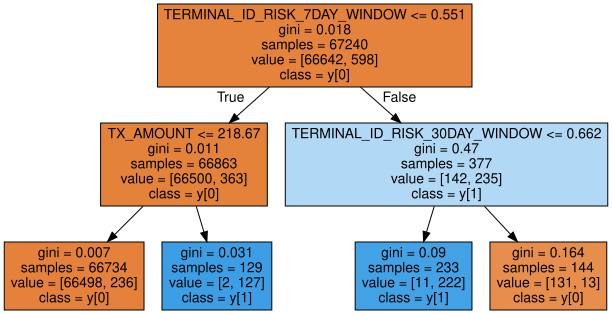

In [17]:
display(graphviz.Source(sklearn.tree.export_graphviz(classifier,feature_names=input_features,class_names=True, filled=True)))

A decision tree allows splitting the input space into different regions, in such a way that the fraudulent transactions are separated from the genuine transactions. The last level of the tree (the leaves) gives the number of fraudulent and genuine training transactions in each of these regions. The color indicates whether a node or leaf of the tree contains a majority of genuine (orange) or fraudulent (blue) transactions.

Each of the five first transactions falls into the first leaf, a region that contains 236 fraudulent transactions and 66498 genuine transactions, that is, a region where the probability of fraud is $\frac{236}{66498+236}=0.003536$.

It is worth noting that the decision tree correctly found that transactions with a high amount are frauds (scenario 1 in the [fraud generation process](Fraud_Scenarios_Generation)). The corresponding region is the second leaf. The decision threshold (218.67) is however not optimally found, as the second leaf contains 2 misclassified genuine transactions. The optimal threshold should be 220, as defined in scenario 1, but it was only empirically fitted from the training data that represent a sample of the overall data distribution.

## performance assessment

Let us finally assess the performance of this decision tree model. We will compute three performance metrics: The AUC ROC, Average Precision (AP), and Card Precision top-$k$ (CP@k). The motivation for these three metrics will be covered in [Chapter 4](Performance_Metrics). For now, it is sufficient to know that:

* The Card Precision top-$k$ is the most pragmatic and interpretable measure. It takes into account the fact that investigators can only check a maximum of $k$ potentially fraudulent cards per day. It is computed by ranking, for every day in the test set, the most fraudulent transactions, and selecting the $k$ cards whose transactions have the highest fraud probabilities. The precision (proportion of actual compromised cards out of predicted compromised cards) is then computed for each day. The Card Precision top-$k$ is the average of these daily precisions. The number $k$ will be set to $100$ (that is, it is assumed that only 100 cards can be checked every day). The metric is described in detail in [Chapter 4, Precision top-k metrics](Precision_Top_K_Metrics).
* The Average Precision is a proxy for the Card Precision top-$k$, that integrates precisions for all possible $k$ values. The metric is described in detail in [Chapter 4, Precision-Recall Curve](Precision_Recall_Curve).
* The AUC ROC is an alternative measure to the Average Precision, which gives more importance to scores obtained with higher $k$ values. It is less relevant in practice since the performances that matter most are those for low $k$ values. We however also report it since it is the most widely used performance metric for fraud detection in the literature. The metric is described in detail in [Chapter 4, Receiving Operating Characteristic (ROC) Curve](Receiving_Operating_Characteristic_Curve).

Note that all three metrics provide values in the interval $[0,1]$, and that higher values mean better performances. 

We provide the implementation below for computing these three performance metrics. The details of their implementation will be covered in [Chapter 4](Performance_Metrics).


## 源码精读 · 原单元格 32

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义交易级评分、单日卡级 Top K 和跨日卡排除的评估函数。

**执行前：** 评分表需要真实标签、连续 predictions、客户编号及日编号。

**执行后：** 调用评分函数返回一行指标表；中间函数还返回每日计数和精确率列表。

这格连续定义三个函数，要先把调用关系串起来：`performance_assessment` 计算交易级 AUC/AP，并调用 `card_precision_top_k`；后者逐天调用 `card_precision_top_k_day`。

人工单日例子：A 有两笔交易 `(分数0.9,标签0)` 和 `(0.1,1)`；B 一笔 `(0.8,0)`；C 一笔 `(0.7,1)`。按客户 groupby 后 `.max()` **对每一列分别取最大值**，A 聚合成分数 0.9、标签 1；两者来自不同交易，这符合“该卡任意交易欺诈则为欺诈卡、最高分作为卡分”的口径，但不能说最高分那笔本身必是欺诈。

按分数降序得到 A、B、C。K=2 时取 A、B，发现欺诈卡列表是 `[A]`，CP@2=`1/2=0.5`。如果候选卡只有三张而 K=5，原函数仍用固定分母 5，而非自动改成 3。这个口径直接影响小样本结果。

跨日函数创建 `list_detected_compromised_cards=[]`，每天先排除此前已发现的欺诈卡。若第一天发现 A，第二天 A 的交易在当日卡排名之前就被移出。它排除的是已发现的欺诈卡，不是所有前一天进入 Top K 的卡；不要把 B 也自动加入。`remove_detected_compromised_cards` 控制是否累计这个状态。

每日精确率放入列表，再取算术平均。平均每日 CP@K 与先拼接所有交易再统一挑一次 K 个，是不同问题。交易级 ROC AUC、AP 则直接用各笔真值和分数；它们也不是卡级列表的同义统计。

最后 `round(3)` 是将结果舍入到三位小数，适合显示，但接近的模型可能因此看起来相同。这个评估中的日间移除假设与训练/测试切分的标签反馈等待机制是两个位置的业务约定，不能因为都处理“已知欺诈”就认为实现完全一样。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
def card_precision_top_k_day(df_day,top_k):
```

执行位置：此处是函数 `card_precision_top_k_day` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `card_precision_top_k_day(df_day, top_k)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `df_day`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `top_k`，本签名未给默认值，调用者需按参数规则提供

- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `top_k`：每天排名前多少个候选的容量参数

**第 3 行**

```python
    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID, 
```

执行位置：本行是注释，不执行。所在上下文：此处是函数 `card_precision_top_k_day` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

原作者的说明性注释：This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID,

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 4 行**

```python
    # and sorts by decreasing order of fraudulent prediction
```

执行位置：本行是注释，不执行。所在上下文：此处是函数 `card_precision_top_k_day` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

原作者的说明性注释：and sorts by decreasing order of fraudulent prediction

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 5 行**

```python
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
```

执行位置：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：重置行索引；drop=True 丢弃旧索引，否则旧索引通常转为列。传入：`drop=False` 是具名参数。

把结果绑定到 `df_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `df_day.groupby('CUSTOMER_ID')`：按键划分组，先形成分组对象；后面的聚合或 apply 才决定输出。传入：位置参数1是 `'CUSTOMER_ID'`
- 求值 `df_day.groupby('CUSTOMER_ID').max()`：取最大值；DataFrame 分列取最大值时不同列可能来自不同原行。这里没有显式传入参数
- 求值 `df_day.groupby('CUSTOMER_ID').max().sort_values(by='predictions', ascending=False)`：按给定列排序；默认返回排序结果，只有明确 inplace 才原地修改。传入：`by='predictions'` 是具名参数；`ascending=False` 是具名参数
- 求值 `df_day.groupby('CUSTOMER_ID').max().sort_values(by='predictions', ascending=False).reset_index(drop=False)`：重置行索引；drop=True 丢弃旧索引，否则旧索引通常转为列。传入：`drop=False` 是具名参数

- 调用 `df_day.groupby('CUSTOMER_ID').max().sort_values(by='predictions', ascending=False).reset_index` 时的具名参数 `drop` 接收 `False`
- 调用 `df_day.groupby('CUSTOMER_ID').max().sort_values` 时的具名参数 `by` 接收 `'predictions'`
- 调用 `df_day.groupby('CUSTOMER_ID').max().sort_values` 时的具名参数 `ascending` 接收 `False`
- 调用 `df_day.groupby` 时的位置参数1：`'CUSTOMER_ID'`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 7 行**

```python
    # Get the top k most suspicious cards
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Get the top k most suspicious cards

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 8 行**

```python
    df_day_top_k=df_day.head(top_k)
```

执行位置：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：取前 n 行，默认前五行；用于查看不等于检查了全表。传入：位置参数1是 `top_k`。

把结果绑定到 `df_day_top_k`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `df_day.head(top_k)`：取前 n 行，默认前五行；用于查看不等于检查了全表。传入：位置参数1是 `top_k`

- 调用 `df_day.head` 时的位置参数1：`top_k`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `top_k`：每天排名前多少个候选的容量参数

**第 9 行**

```python
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
```

执行位置：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按 `list` 对输入进行构造或类型转换。传入：位置参数1是 `df_day_top_k[df_day_top_k.TX_FRAUD == 1].CUSTOMER_ID`。

把结果绑定到 `list_detected_compromised_cards`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `df_day_top_k.TX_FRAUD == 1`：判断`df_day_top_k.TX_FRAUD` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `df_day_top_k[df_day_top_k.TX_FRAUD == 1]`：从 `df_day_top_k` 中按 `df_day_top_k.TX_FRAUD == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `list(df_day_top_k[df_day_top_k.TX_FRAUD == 1].CUSTOMER_ID)`：按 `list` 对输入进行构造或类型转换。传入：位置参数1是 `df_day_top_k[df_day_top_k.TX_FRAUD == 1].CUSTOMER_ID`

- 调用 `list` 时的位置参数1：`df_day_top_k[df_day_top_k.TX_FRAUD == 1].CUSTOMER_ID`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级
- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息

**第 11 行**

```python
    # Compute precision top k
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Compute precision top k

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 12 行**

```python
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
```

执行位置：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：先取得 取得对象长度：列表是元素数，DataFrame通常是行数。传入：位置参数1是 `list_detected_compromised_cards`，再与 变量 `top_k` 当前引用的值 做“除以”；数组或Series时通常逐元素计算，形状或索引须兼容。

把结果绑定到 `card_precision_top_k`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `len(list_detected_compromised_cards)`：取得对象长度：列表是元素数，DataFrame通常是行数。传入：位置参数1是 `list_detected_compromised_cards`
- 求值 `len(list_detected_compromised_cards) / top_k`：先取得 取得对象长度：列表是元素数，DataFrame通常是行数。传入：位置参数1是 `list_detected_compromised_cards`，再与 变量 `top_k` 当前引用的值 做“除以”；数组或Series时通常逐元素计算，形状或索引须兼容

- 调用 `len` 时的位置参数1：`list_detected_compromised_cards`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `top_k`：每天排名前多少个候选的容量参数

**第 14 行**

```python
    return list_detected_compromised_cards, card_precision_top_k
```

执行位置：仅在调用 `card_precision_top_k_day` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：含 2 项的元组：变量 `list_detected_compromised_cards` 当前引用的值；变量 `card_precision_top_k` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 求值 `(list_detected_compromised_cards, card_precision_top_k)`：含 2 项的元组：变量 `list_detected_compromised_cards` 当前引用的值；变量 `card_precision_top_k` 当前引用的值

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 16 行**

```python
def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):
```

执行位置：此处是函数 `card_precision_top_k` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `predictions_df`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `top_k`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `remove_detected_compromised_cards` 的默认表达式 `True`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `predictions_df`：用于评分的交易表，包含标签及对应分数
- `top_k`：每天排名前多少个候选的容量参数

**第 18 行**

```python
    # Sort days by increasing order
```

执行位置：本行是注释，不执行。所在上下文：此处是函数 `card_precision_top_k` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

原作者的说明性注释：Sort days by increasing order

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 19 行**

```python
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按 `list` 对输入进行构造或类型转换。传入：位置参数1是 `predictions_df['TX_TIME_DAYS'].unique()`。

把结果绑定到 `list_days`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `predictions_df['TX_TIME_DAYS']`：从 `predictions_df` 中按 `'TX_TIME_DAYS'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `predictions_df['TX_TIME_DAYS'].unique()`：取得去重后的不同值，顺序不自动保证已经排序。这里没有显式传入参数
- 求值 `list(predictions_df['TX_TIME_DAYS'].unique())`：按 `list` 对输入进行构造或类型转换。传入：位置参数1是 `predictions_df['TX_TIME_DAYS'].unique()`

- 调用 `list` 时的位置参数1：`predictions_df['TX_TIME_DAYS'].unique()`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 20 行**

```python
    list_days.sort()
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

对该对象进行排序；Python 列表的 sort 原地修改并返回 None。这里没有显式传入参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `list_days.sort()`：对该对象进行排序；Python 列表的 sort 原地修改并返回 None。这里没有显式传入参数

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 22 行**

```python
    # At first, the list of detected compromised cards is empty
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：At first, the list of detected compromised cards is empty

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 23 行**

```python
    list_detected_compromised_cards = []
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：一个空列表。

把结果绑定到 `list_detected_compromised_cards`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[]`：一个空列表

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 25 行**

```python
    card_precision_top_k_per_day_list = []
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：一个空列表。

把结果绑定到 `card_precision_top_k_per_day_list`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[]`：一个空列表

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 26 行**

```python
    nb_compromised_cards_per_day = []
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：一个空列表。

把结果绑定到 `nb_compromised_cards_per_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[]`：一个空列表

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 28 行**

```python
    # For each day, compute precision top k
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：For each day, compute precision top k

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 29 行**

```python
    for day in list_days:
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

遍历 `list_days`，每次把取出的项交给 `day`。

对每项执行缩进体；循环变量通常被下一项覆盖，累计结果需另放列表、表格或计数器。空可迭代对象不会执行循环体。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 31 行**

```python
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

先计算右侧：从 `predictions_df` 中按 `predictions_df['TX_TIME_DAYS'] == day` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `df_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `predictions_df['TX_TIME_DAYS']`：从 `predictions_df` 中按 `'TX_TIME_DAYS'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `predictions_df['TX_TIME_DAYS'] == day`：判断`predictions_df['TX_TIME_DAYS']` 是否等于 `day`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `predictions_df[predictions_df['TX_TIME_DAYS'] == day]`：从 `predictions_df` 中按 `predictions_df['TX_TIME_DAYS'] == day` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 32 行**

```python
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

先计算右侧：从 `df_day` 中按 `['predictions', 'CUSTOMER_ID', 'TX_FRAUD']` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `df_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `['predictions', 'CUSTOMER_ID', 'TX_FRAUD']`：含 3 项的列表：字符串 `predictions`（文字，不是同名变量）；字符串 `CUSTOMER_ID`（文字，不是同名变量）；字符串 `TX_FRAUD`（文字，不是同名变量）
- 求值 `df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]`：从 `df_day` 中按 `['predictions', 'CUSTOMER_ID', 'TX_FRAUD']` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 34 行**

```python
        # Let us remove detected compromised cards from the set of daily transactions
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

原作者的说明性注释：Let us remove detected compromised cards from the set of daily transactions

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 35 行**

```python
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

先计算右侧：从 `df_day` 中按 `df_day.CUSTOMER_ID.isin(list_detected_compromised_cards) == False` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

把结果绑定到 `df_day`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)`：逐项判断值是否在给定集合内，得到布尔筛选条件。传入：位置参数1是 `list_detected_compromised_cards`
- 求值 `df_day.CUSTOMER_ID.isin(list_detected_compromised_cards) == False`：判断`df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)` 是否等于 `False`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards) == False]`：从 `df_day` 中按 `df_day.CUSTOMER_ID.isin(list_detected_compromised_cards) == False` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- 调用 `df_day.CUSTOMER_ID.isin` 时的位置参数1：`list_detected_compromised_cards`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级

**第 37 行**

```python
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `len(df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique())`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `df_day.TX_FRAUD == 1`：判断`df_day.TX_FRAUD` 是否等于 `1`；标量比较通常给一个布尔值，数组或Series比较通常逐项给布尔值
- 求值 `df_day[df_day.TX_FRAUD == 1]`：从 `df_day` 中按 `df_day.TX_FRAUD == 1` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique()`：取得去重后的不同值，顺序不自动保证已经排序。这里没有显式传入参数
- 求值 `len(df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique())`：取得对象长度：列表是元素数，DataFrame通常是行数。传入：位置参数1是 `df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique()`
- 求值 `nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique()))`：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `len(df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique())`

- 调用 `nb_compromised_cards_per_day.append` 时的位置参数1：`len(df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique())`；先求出该表达式再传入
- 调用 `len` 时的位置参数1：`df_day[df_day.TX_FRAUD == 1].CUSTOMER_ID.unique()`；先求出该表达式再传入

- 比较符生成判断结果；`==` 比较值是否相等，`=` 用于赋值或具名参数。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `CUSTOMER_ID`：客户标识，不表示连续风险等级
- `TX_FRAUD`：0/1 欺诈标签，属于监督目标或事后评估信息

**第 39 行**

```python
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

先计算右侧：调用 `card_precision_top_k_day`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `df_day`；位置参数2是 `top_k`。

按位置把右侧多个返回值解包给 `(detected_compromised_cards, card_precision_top_k)`；两侧数量必须匹配，星号解包除外。

- 求值 `card_precision_top_k_day(df_day, top_k)`：调用 `card_precision_top_k_day`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `df_day`；位置参数2是 `top_k`

- 调用 `card_precision_top_k_day` 时的位置参数1：`df_day`；先求出该表达式再传入
- 调用 `card_precision_top_k_day` 时的位置参数2：`top_k`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `top_k`：每天排名前多少个候选的容量参数

**第 41 行**

```python
        card_precision_top_k_per_day_list.append(card_precision_top_k)
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `card_precision_top_k`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `card_precision_top_k_per_day_list.append(card_precision_top_k)`：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `card_precision_top_k`

- 调用 `card_precision_top_k_per_day_list.append` 时的位置参数1：`card_precision_top_k`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 43 行**

```python
        # Let us update the list of detected compromised cards
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

原作者的说明性注释：Let us update the list of detected compromised cards

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 44 行**

```python
        if remove_detected_compromised_cards:
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行

判断条件：变量 `remove_detected_compromised_cards` 当前引用的值。

条件成立才执行相应缩进分支，不成立则转到后续 elif/else 或跳过。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 45 行**

```python
            list_detected_compromised_cards.extend(detected_compromised_cards)
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `list_days` 取得一项赋给 `day`后走到本行时执行；仅在条件 `remove_detected_compromised_cards` 成立的分支中执行

把可迭代对象中的元素逐个加入 Python 列表末尾，原地修改并返回 None。传入：位置参数1是 `detected_compromised_cards`。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `list_detected_compromised_cards.extend(detected_compromised_cards)`：把可迭代对象中的元素逐个加入 Python 列表末尾，原地修改并返回 None。传入：位置参数1是 `detected_compromised_cards`

- 调用 `list_detected_compromised_cards.extend` 时的位置参数1：`detected_compromised_cards`；先求出该表达式再传入

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 47 行**

```python
    # Compute the mean
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Compute the mean

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 48 行**

```python
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：按对象、轴或窗口求平均，先明确分母是哪一批记录。这里没有显式传入参数。

把结果绑定到 `mean_card_precision_top_k`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `np.array(card_precision_top_k_per_day_list)`：将输入构造成 NumPy 数组；维度取决于嵌套结构和参数。传入：位置参数1是 `card_precision_top_k_per_day_list`
- 求值 `np.array(card_precision_top_k_per_day_list).mean()`：按对象、轴或窗口求平均，先明确分母是哪一批记录。这里没有显式传入参数

- 调用 `np.array` 时的位置参数1：`card_precision_top_k_per_day_list`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `np`：NumPy 的导入别名，提供数组和数值计算工具

**第 50 行**

```python
    # Returns precision top k per day as a list, and resulting mean
```

执行位置：本行是注释，不执行。所在上下文：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

原作者的说明性注释：Returns precision top k per day as a list, and resulting mean

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 51 行**

```python
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k
```

执行位置：仅在调用 `card_precision_top_k` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：含 3 项的元组：变量 `nb_compromised_cards_per_day` 当前引用的值；变量 `card_precision_top_k_per_day_list` 当前引用的值；变量 `mean_card_precision_top_k` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 求值 `(nb_compromised_cards_per_day, card_precision_top_k_per_day_list, mean_card_precision_top_k)`：含 3 项的元组：变量 `nb_compromised_cards_per_day` 当前引用的值；变量 `card_precision_top_k_per_day_list` 当前引用的值；变量 `mean_card_precision_top_k` 当前引用的值

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 53 行**

```python
def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
```

执行位置：此处是函数 `performance_assessment` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `performance_assessment(predictions_df, output_feature='TX_FRAUD', prediction_feature='predictions', top_k_list=[100], rounded=True)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 求值 `[100]`：含 1 项的列表：常量 `100`

- 定义参数 `predictions_df`，本签名未给默认值，调用者需按参数规则提供
- 定义参数 `output_feature` 的默认表达式 `'TX_FRAUD'`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `output_feature`：目标标签列的名称，通常是 TX_FRAUD
- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 54 行**

```python
                           prediction_feature='predictions', top_k_list=[100],
```

执行位置：此处是函数 `performance_assessment` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第53行函数 `performance_assessment` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 求值 `[100]`：含 1 项的列表：常量 `100`

- 定义参数 `prediction_feature` 的默认表达式 `'predictions'`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象
- 定义参数 `top_k_list` 的默认表达式 `[100]`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 55 行**

```python
                           rounded=True):
```

执行位置：此处是函数 `performance_assessment` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第53行函数 `performance_assessment` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `rounded` 的默认表达式 `True`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 57 行**

```python
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：用真实标签与连续分数计算 ROC AUC，需要合适的类别覆盖。传入：位置参数1是 `predictions_df[output_feature]`；位置参数2是 `predictions_df[prediction_feature]`。

把结果绑定到 `AUC_ROC`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `predictions_df[output_feature]`：从 `predictions_df` 中按 `output_feature` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `predictions_df[prediction_feature]`：从 `predictions_df` 中按 `prediction_feature` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])`：用真实标签与连续分数计算 ROC AUC，需要合适的类别覆盖。传入：位置参数1是 `predictions_df[output_feature]`；位置参数2是 `predictions_df[prediction_feature]`

- 调用 `metrics.roc_auc_score` 时的位置参数1：`predictions_df[output_feature]`；先求出该表达式再传入
- 调用 `metrics.roc_auc_score` 时的位置参数2：`predictions_df[prediction_feature]`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `output_feature`：目标标签列的名称，通常是 TX_FRAUD
- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 58 行**

```python
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：从真实标签和连续分数计算 Average Precision，不能当作 PR 梯形积分的同名替代。传入：位置参数1是 `predictions_df[output_feature]`；位置参数2是 `predictions_df[prediction_feature]`。

把结果绑定到 `AP`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `predictions_df[output_feature]`：从 `predictions_df` 中按 `output_feature` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `predictions_df[prediction_feature]`：从 `predictions_df` 中按 `prediction_feature` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])`：从真实标签和连续分数计算 Average Precision，不能当作 PR 梯形积分的同名替代。传入：位置参数1是 `predictions_df[output_feature]`；位置参数2是 `predictions_df[prediction_feature]`

- 调用 `metrics.average_precision_score` 时的位置参数1：`predictions_df[output_feature]`；先求出该表达式再传入
- 调用 `metrics.average_precision_score` 时的位置参数2：`predictions_df[prediction_feature]`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `output_feature`：目标标签列的名称，通常是 TX_FRAUD
- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 60 行**

```python
    performances = pd.DataFrame([[AUC_ROC, AP]], 
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。传入：位置参数1是 `[[AUC_ROC, AP]]`；`columns=['AUC ROC', 'Average precision']` 是具名参数。

把结果绑定到 `performances`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[AUC_ROC, AP]`：含 2 项的列表：变量 `AUC_ROC` 当前引用的值；变量 `AP` 当前引用的值
- 求值 `[[AUC_ROC, AP]]`：含 1 项的列表：含 2 项的列表：变量 `AUC_ROC` 当前引用的值；变量 `AP` 当前引用的值
- 求值 `['AUC ROC', 'Average precision']`：含 2 项的列表：字符串 `AUC ROC`（文字，不是同名变量）；字符串 `Average precision`（文字，不是同名变量）
- 求值 `pd.DataFrame([[AUC_ROC, AP]], columns=['AUC ROC', 'Average precision'])`：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。传入：位置参数1是 `[[AUC_ROC, AP]]`；`columns=['AUC ROC', 'Average precision']` 是具名参数

- 调用 `pd.DataFrame` 时的位置参数1：`[[AUC_ROC, AP]]`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `pd`：pandas 的导入别名，提供数据表工具

**第 61 行**

```python
                           columns=['AUC ROC','Average precision'])
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

这是从代码第 60 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 60 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `['AUC ROC', 'Average precision']`：含 2 项的列表：字符串 `AUC ROC`（文字，不是同名变量）；字符串 `Average precision`（文字，不是同名变量）

- 调用 `pd.DataFrame` 时的具名参数 `columns` 接收 `['AUC ROC', 'Average precision']`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 63 行**

```python
    for top_k in top_k_list:
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

遍历 `top_k_list`，每次把取出的项交给 `top_k`。

对每项执行缩进体；循环变量通常被下一项覆盖，累计结果需另放列表、表格或计数器。空可迭代对象不会执行循环体。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `top_k`：每天排名前多少个候选的容量参数

**第 65 行**

```python
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `top_k_list` 取得一项赋给 `top_k`后走到本行时执行

先计算右侧：调用 `card_precision_top_k`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；位置参数2是 `top_k`。

按位置把右侧多个返回值解包给 `(_, _, mean_card_precision_top_k)`；两侧数量必须匹配，星号解包除外。

- 求值 `card_precision_top_k(predictions_df, top_k)`：调用 `card_precision_top_k`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；位置参数2是 `top_k`

- 调用 `card_precision_top_k` 时的位置参数1：`predictions_df`；先求出该表达式再传入
- 调用 `card_precision_top_k` 时的位置参数2：`top_k`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `predictions_df`：用于评分的交易表，包含标签及对应分数
- `top_k`：每天排名前多少个候选的容量参数

**第 66 行**

```python
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `top_k_list` 取得一项赋给 `top_k`后走到本行时执行

先计算右侧：变量 `mean_card_precision_top_k` 当前引用的值。

再把结果写到 `performances['Card Precision@' + str(top_k)]` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- 调用 `str` 时的位置参数1：`top_k`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `top_k`：每天排名前多少个候选的容量参数

**第 68 行**

```python
    if rounded:
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

判断条件：变量 `rounded` 当前引用的值。

条件成立才执行相应缩进分支，不成立则转到后续 elif/else 或跳过。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 69 行**

```python
        performances = performances.round(3)
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体；仅在条件 `rounded` 成立的分支中执行

先计算右侧：按接收对象的舍入规则生成指定精度的数值；不只是显示格式，赋回后会影响后续计算。传入：位置参数1是 `3`。

把结果绑定到 `performances`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `performances.round(3)`：按接收对象的舍入规则生成指定精度的数值；不只是显示格式，赋回后会影响后续计算。传入：位置参数1是 `3`

- 调用 `performances.round` 时的位置参数1：`3`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 71 行**

```python
    return performances
```

执行位置：仅在调用 `performance_assessment` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：变量 `performances` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [18]:
def card_precision_top_k_day(df_day,top_k):
    
    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID, 
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k

def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Sort days by increasing order
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # At first, the list of detected compromised cards is empty
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Let us remove detected compromised cards from the set of daily transactions
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Let us update the list of detected compromised cards
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k

def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances

Let us compute the performance in terms of AUC ROC, Average Precision (AP), and Card Precision top 100 (CP@100) for the decision tree.

## 源码精读 · 原单元格 34

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 组装当前模型的评分表并调用指标函数。

**执行前：** 已有 test_df 和 predictions_test，二者顺序对应。

**执行后：** 显示 AUC、AP、Card Precision@100；原 test_df 也会拥有 predictions 列。

`predictions_df=test_df` 没有 `.copy()`，两个变量指向同一表对象。随后对 predictions_df 新增 `predictions` 列，test_df 通过另一个名称也能看到这个改动。它不是专门创建了一张隔离的评分副本。

调用 `performance_assessment(...,top_k_list=[100])`，方括号表示希望依次评估的 K 值列表；这里只有一个 K。若改为 `[20,100]`，循环会生成两个卡级指标列。模型训练在前面已完成，这格只是把已有预测与真值对齐评分。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
predictions_df=test_df
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：变量 `test_df` 当前引用的值。

把结果绑定到 `predictions_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

- `predictions_df`：用于评分的交易表，包含标签及对应分数
- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 2 行**

```python
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：从 `model_and_predictions_dictionary` 中按 `'predictions_test'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

再把结果写到 `predictions_df['predictions']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- 求值 `model_and_predictions_dictionary['predictions_test']`：从 `model_and_predictions_dictionary` 中按 `'predictions_test'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 4 行**

```python
performance_assessment(predictions_df, top_k_list=[100])
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

调用 `performance_assessment`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；`top_k_list=[100]` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `[100]`：含 1 项的列表：常量 `100`
- 求值 `performance_assessment(predictions_df, top_k_list=[100])`：调用 `performance_assessment`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；`top_k_list=[100]` 是具名参数

- 调用 `performance_assessment` 时的位置参数1：`predictions_df`；先求出该表达式再传入
- 调用 `performance_assessment` 时的具名参数 `top_k_list` 接收 `[100]`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [19]:
predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.763,0.496,0.241


The most interpretable metric is the Card Precision@100, which tells us that every day, 24% of the cards with the highest fraudulent scores were indeed compromised. Since the percentage of frauds in the test set is 0.7%, this proportion of detected frauds is high and means that the classifier indeed manages to do much better than chance. 

The interpretation of the AUC ROC and Average Precision is less straightforward. However, by definition, it is known that a random classifier would give an AUC ROC of 0.5, and an Average Precision of 0.007 (the proportion of frauds in the test set). The obtained values are much higher (0.764) and (0.496), confirming the ability of the classifier to provide much better predictions than a random model.

Note: The performances for a random model can be computed by simply setting all predictions to a probability of $0.5$:


## 源码精读 · 原单元格 36

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 用所有交易都为 0.5 的常数分数做参照。

**执行前：** predictions_df 与 test_df 仍是同一表，包含真实标签。

**执行后：** predictions 列被全部覆盖为 0.5，再按相同函数评估。

给整列赋标量 0.5，pandas 会将该值广播到各行，不是只改第一笔，也不是给每笔独立抽一个随机分数。所有分数相同，模型不能按风险区分交易。

在有两个类别的常见条件下，ROC AUC 对完全并列分数为 0.5，AP 对应类别基准比例；卡级 Top K 还受到并列时排序顺序的影响，因此不能说这段代码已经完成了多次随机抽卡实验并估计平均卡精确率。先前另一个命名列 `TX_FRAUD_PREDICTED` 若仍在，不会因为覆盖 `predictions` 就自动同步变成 0.5。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
predictions_df['predictions']=0.5
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：常量 `0.5`。

再把结果写到 `predictions_df['predictions']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 3 行**

```python
performance_assessment(predictions_df, top_k_list=[100])
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

调用 `performance_assessment`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；`top_k_list=[100]` 是具名参数。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

- 求值 `[100]`：含 1 项的列表：常量 `100`
- 求值 `performance_assessment(predictions_df, top_k_list=[100])`：调用 `performance_assessment`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；`top_k_list=[100]` 是具名参数

- 调用 `performance_assessment` 时的位置参数1：`predictions_df`；先求出该表达式再传入
- 调用 `performance_assessment` 时的具名参数 `top_k_list` 接收 `[100]`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [20]:
predictions_df['predictions']=0.5
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.5,0.007,0.017


(Baseline_FDS_Performances_Simulation)=
## Performances using standard prediction models

We now have all the building blocks to train and assess other classifiers. Besides the decision tree with depth 2, let us train four other prediction models: a *decision tree* with unlimited depth, a *logistic regression* model, a *random forest*, and a boosting model (refer to the import cell for library details). These models are the most commonly used in benchmarks in the fraud detection literature {cite}`yousefi2019comprehensive,priscilla2019credit`. 
 
For this purpose, let us first create a dictionary of `sklearn` classifiers that instantiates each of these classifiers. We then train and compute the predictions for each of these classifiers using the `fit_model_and_get_predictions` function.

## 源码精读 · 原单元格 39

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 训练五类分类器，并将各自结果按名称收集到字典。

**执行前：** 有相同切分的数据和 15 个输入特征。

**执行后：** fitted_models_and_predictions_dictionary 的每个键对应一个模型的预测与耗时结果字典。

外层字典把“可读模型名”映射到估计器对象：逻辑回归、浅树、无限制树、随机森林、XGBoost。构造它们时仍未完成训练。`for classifier_name in classifiers_dictionary` 每轮只取得一个字典键，即模型名称；循环体再通过 `classifiers_dictionary[classifier_name]` 找到对应对象。本格不是通过 items() 同时解包键和值，后面的汇总函数才用到那种写法。

人工容器追踪：初始结果字典 `{}`；第一轮结束加入 `'Logistic regression': {...}`；第二轮再加入浅树键。每个内部字典保留 classifier、predictions_test、predictions_train 和耗时，因此后面的统一函数可以按同一格式读取，不必为每种模型另写评分代码。

这里调用训练流程没有写 `scale=False`，所以采用默认 True。公共缩放函数会修改传入数据表，因此多轮使用同一 train_df/test_df 时要意识到状态会被重复处理；不能将这段实验包装成完全无副作用的流水线。`n_jobs=-1` 是并行资源设置，不是多运行一次实验；random_state 是随机过程设置，也不保证跨所有环境逐位一致。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0), 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：键值字典：键 `'Logistic regression'` 对应 调用 `sklearn.linear_model.LogisticRegression`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；键 `'Decision tree with depth of two'` 对应 调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`max_depth=2` 是具名参数；`random_state=0` 是具名参数；键 `'Decision tree - unlimited depth'` 对应 调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；键 `'Random forest'` 对应 调用 `sklearn.ensemble.RandomForestClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数；键 `'XGBoost'` 对应 调用 `xgboost.XGBClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数。

把结果绑定到 `classifiers_dictionary`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `sklearn.linear_model.LogisticRegression(random_state=0)`：调用 `sklearn.linear_model.LogisticRegression`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数
- 求值 `sklearn.tree.DecisionTreeClassifier(max_depth=2, random_state=0)`：调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`max_depth=2` 是具名参数；`random_state=0` 是具名参数
- 求值 `sklearn.tree.DecisionTreeClassifier(random_state=0)`：调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数
- 求值 `-1`：取相反数，作用对象是 `1`
- 求值 `sklearn.ensemble.RandomForestClassifier(random_state=0, n_jobs=-1)`：调用 `sklearn.ensemble.RandomForestClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数
- 求值 `-1`：取相反数，作用对象是 `1`
- 求值 `xgboost.XGBClassifier(random_state=0, n_jobs=-1)`：调用 `xgboost.XGBClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数
- 求值 `{'Logistic regression': sklearn.linear_model.LogisticRegression(random_state=0), 'Decision tree with depth of two': sklearn.tree.DecisionTreeClassifier(max_depth=2, random_state=0), 'Decision tree - unlimited depth': sklearn.tree.DecisionTreeClassifier(random_state=0), 'Random forest': sklearn.ensemble.RandomForestClassifier(random_state=0, n_jobs=-1), 'XGBoost': xgboost.XGBClassifier(random_state=0, n_jobs=-1)}`：键值字典：键 `'Logistic regression'` 对应 调用 `sklearn.linear_model.LogisticRegression`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；键 `'Decision tree with depth of two'` 对应 调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`max_depth=2` 是具名参数；`random_state=0` 是具名参数；键 `'Decision tree - unlimited depth'` 对应 调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；键 `'Random forest'` 对应 调用 `sklearn.ensemble.RandomForestClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数；键 `'XGBoost'` 对应 调用 `xgboost.XGBClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数

- 调用 `sklearn.linear_model.LogisticRegression` 时的具名参数 `random_state` 接收 `0`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `random_state`：随机过程的种子设置

**第 2 行**

```python
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0), 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 1 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 1 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `sklearn.tree.DecisionTreeClassifier(max_depth=2, random_state=0)`：调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`max_depth=2` 是具名参数；`random_state=0` 是具名参数

- 调用 `sklearn.tree.DecisionTreeClassifier` 时的具名参数 `max_depth` 接收 `2`
- 调用 `sklearn.tree.DecisionTreeClassifier` 时的具名参数 `random_state` 接收 `0`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `random_state`：随机过程的种子设置

**第 3 行**

```python
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0), 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 1 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 1 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `sklearn.tree.DecisionTreeClassifier(random_state=0)`：调用 `sklearn.tree.DecisionTreeClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数

- 调用 `sklearn.tree.DecisionTreeClassifier` 时的具名参数 `random_state` 接收 `0`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `random_state`：随机过程的种子设置

**第 4 行**

```python
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 1 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 1 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `-1`：取相反数，作用对象是 `1`
- 求值 `sklearn.ensemble.RandomForestClassifier(random_state=0, n_jobs=-1)`：调用 `sklearn.ensemble.RandomForestClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数

- 调用 `sklearn.ensemble.RandomForestClassifier` 时的具名参数 `random_state` 接收 `0`
- 调用 `sklearn.ensemble.RandomForestClassifier` 时的具名参数 `n_jobs` 接收 `-1`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `random_state`：随机过程的种子设置

**第 5 行**

```python
                        'XGBoost':xgboost.XGBClassifier(random_state=0,n_jobs=-1),
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 1 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 1 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `-1`：取相反数，作用对象是 `1`
- 求值 `xgboost.XGBClassifier(random_state=0, n_jobs=-1)`：调用 `xgboost.XGBClassifier`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：`random_state=0` 是具名参数；`n_jobs=-1` 是具名参数

- 调用 `xgboost.XGBClassifier` 时的具名参数 `random_state` 接收 `0`
- 调用 `xgboost.XGBClassifier` 时的具名参数 `n_jobs` 接收 `-1`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `random_state`：随机过程的种子设置

**第 6 行**

```python
                       }
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 1 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。

与第 1 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 8 行**

```python
fitted_models_and_predictions_dictionary={}
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：键值字典：。

把结果绑定到 `fitted_models_and_predictions_dictionary`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `{}`：键值字典：

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。

**第 10 行**

```python
for classifier_name in classifiers_dictionary:
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

遍历 `classifiers_dictionary`，每次把取出的项交给 `classifier_name`。

对每项执行缩进体；循环变量通常被下一项覆盖，累计结果需另放列表、表格或计数器。空可迭代对象不会执行循环体。

- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。

**第 12 行**

```python
    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df, 
```

执行位置：属于循环体，仅在本轮从 `classifiers_dictionary` 取得一项赋给 `classifier_name`后走到本行时执行

先计算右侧：调用 `fit_model_and_get_predictions`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `classifiers_dictionary[classifier_name]`；位置参数2是 `train_df`；位置参数3是 `test_df`；`input_features=input_features` 是具名参数；`output_feature=output_feature` 是具名参数。

把结果绑定到 `model_and_predictions`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `classifiers_dictionary[classifier_name]`：从 `classifiers_dictionary` 中按 `classifier_name` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df, input_features=input_features, output_feature=output_feature)`：调用 `fit_model_and_get_predictions`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `classifiers_dictionary[classifier_name]`；位置参数2是 `train_df`；位置参数3是 `test_df`；`input_features=input_features` 是具名参数；`output_feature=output_feature` 是具名参数

- 调用 `fit_model_and_get_predictions` 时的位置参数1：`classifiers_dictionary[classifier_name]`；先求出该表达式再传入
- 调用 `fit_model_and_get_predictions` 时的位置参数2：`train_df`；先求出该表达式再传入
- 调用 `fit_model_and_get_predictions` 时的位置参数3：`test_df`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认
- `train_df`：选出的训练交易表

**第 13 行**

```python
                                                                                  input_features=input_features,
```

执行位置：属于循环体，仅在本轮从 `classifiers_dictionary` 取得一项赋给 `classifier_name`后走到本行时执行

这是从代码第 12 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 12 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `fit_model_and_get_predictions` 时的具名参数 `input_features` 接收 `input_features`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `input_features`：模型输入列名列表，列的数量和顺序决定输入矩阵

**第 14 行**

```python
                                                                                output_feature=output_feature)
```

执行位置：属于循环体，仅在本轮从 `classifiers_dictionary` 取得一项赋给 `classifier_name`后走到本行时执行

这是从代码第 12 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 12 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `fit_model_and_get_predictions` 时的具名参数 `output_feature` 接收 `output_feature`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `output_feature`：目标标签列的名称，通常是 TX_FRAUD

**第 15 行**

```python
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions
```

执行位置：属于循环体，仅在本轮从 `classifiers_dictionary` 取得一项赋给 `classifier_name`后走到本行时执行

先计算右侧：变量 `model_and_predictions` 当前引用的值。

再把结果写到 `fitted_models_and_predictions_dictionary[classifier_name]` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [21]:
classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0), 
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0), 
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0), 
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                        'XGBoost':xgboost.XGBClassifier(random_state=0,n_jobs=-1),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:
    
    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df, 
                                                                                  input_features=input_features,
                                                                                output_feature=output_feature)
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions


[11:36:54] WARNING: /private/var/folders/2y/mv3z1v0945b60_l2bzjwpzj80000gn/T/pip-install-v081hmhv/xgboost_5f8c79180547427599a229ec66faab67/build/temp.macosx-10.9-x86_64-3.9/xgboost/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


Let us finally assess the prediction performances of these five models, on the test set and the training set, and their execution times.

## 源码精读 · 原单元格 41

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义将模型结果集合统一转为性能对比表的函数。

**执行前：** 模型集合是嵌套字典；transactions_df 必须对应所选择的训练或测试预测。

**执行后：** 调用后每个模型一行，列是 AUC、AP 与指定卡级指标。

初始 `performances=pd.DataFrame()` 是空表。每轮从内部字典取指定预测数组，写到评分表，然后调用性能函数得到一行结果。把该行索引设为分类器名称，再追加到汇总表。

这里 `.append()` 的接收对象是 DataFrame，它是教材使用的旧版 pandas 接口，与模拟数据函数里的 Python 列表追加不同：旧接口返回新表，所以左侧必须接回 `performances=...`。不要把“列表 append 返回 None”的规则照搬到这一行；也不要把旧接口误认为当前各版本都提供。保持原文有助于认清版本差异，真正迁移时再考虑用 concat 收集结果。

`predictions_df=transactions_df` 仍是别名，循环会不断覆盖同一个输入表的预测列。因此函数返回的汇总表与输入表最后留下哪个模型分数，是两个不同层面的输出效果。

**需要辨清的地方**

- 原代码含旧 pandas DataFrame.append；未在当前环境执行兼容性验证。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
```

执行位置：此处是函数 `performance_assessment_model_collection` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `performance_assessment_model_collection(fitted_models_and_predictions_dictionary, transactions_df, type_set='test', top_k_list=[100])`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 求值 `[100]`：含 1 项的列表：常量 `100`

- 定义参数 `fitted_models_and_predictions_dictionary`，本签名未给默认值，调用者需按参数规则提供

- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

**第 2 行**

```python
                                            transactions_df, 
```

执行位置：此处是函数 `performance_assessment_model_collection` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第1行函数 `performance_assessment_model_collection` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `transactions_df`，本签名未给默认值，调用者需按参数规则提供

- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 3 行**

```python
                                            type_set='test',
```

执行位置：此处是函数 `performance_assessment_model_collection` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第1行函数 `performance_assessment_model_collection` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 定义参数 `type_set` 的默认表达式 `'test'`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 4 行**

```python
                                            top_k_list=[100]):
```

执行位置：此处是函数 `performance_assessment_model_collection` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

这是第1行函数 `performance_assessment_model_collection` 定义签名的续行，继续声明参数或闭合签名；不是调用函数。

等完整定义建立函数对象；默认值在定义时求值，缩进函数体不会因此执行。

- 求值 `[100]`：含 1 项的列表：常量 `100`

- 定义参数 `top_k_list` 的默认表达式 `[100]`；它在定义时求值一次，调用未提供该参数时才采用这个默认对象

- 函数定义签名中的 `参数名=表达式` 指定默认值；默认表达式在定义时求值，不能当成一次实际传参或函数体赋值。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 6 行**

```python
    performances=pd.DataFrame() 
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。这里没有显式传入参数。

把结果绑定到 `performances`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `pd.DataFrame()`：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `pd`：pandas 的导入别名，提供数据表工具

**第 8 行**

```python
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体

遍历 `fitted_models_and_predictions_dictionary.items()`，每次把取出的项交给 `(classifier_name, model_and_predictions)`。

对每项执行缩进体；循环变量通常被下一项覆盖，累计结果需另放列表、表格或计数器。空可迭代对象不会执行循环体。

- 求值 `fitted_models_and_predictions_dictionary.items()`：遍历字典的键和值成对的条目，常与两个循环变量解包配合。这里没有显式传入参数

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 10 行**

```python
        predictions_df=transactions_df
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：变量 `transactions_df` 当前引用的值。

把结果绑定到 `predictions_df`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `predictions_df`：用于评分的交易表，包含标签及对应分数
- `transactions_df`：交易明细 DataFrame，每行通常对应一笔交易

**第 12 行**

```python
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：从 `model_and_predictions` 中按 `'predictions_' + type_set` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

再把结果写到 `predictions_df['predictions']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- 求值 `'predictions_' + type_set`：先计算 `'predictions_'` 与 `type_set`；数值的 + 是相加，列表或字符串的 + 是按顺序拼接，数组/Series则按各自对齐规则计算
- 求值 `model_and_predictions['predictions_' + type_set]`：从 `model_and_predictions` 中按 `'predictions_' + type_set` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 14 行**

```python
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：调用 `performance_assessment`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；`output_feature='TX_FRAUD'` 是具名参数；`prediction_feature='predictions'` 是具名参数；`top_k_list=top_k_list` 是具名参数。

把结果绑定到 `performances_model`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `performance_assessment(predictions_df, output_feature='TX_FRAUD', prediction_feature='predictions', top_k_list=top_k_list)`：调用 `performance_assessment`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `predictions_df`；`output_feature='TX_FRAUD'` 是具名参数；`prediction_feature='predictions'` 是具名参数；`top_k_list=top_k_list` 是具名参数

- 调用 `performance_assessment` 时的位置参数1：`predictions_df`；先求出该表达式再传入
- 调用 `performance_assessment` 时的具名参数 `output_feature` 接收 `'TX_FRAUD'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `output_feature`：目标标签列的名称，通常是 TX_FRAUD
- `predictions_df`：用于评分的交易表，包含标签及对应分数

**第 15 行**

```python
                                                   prediction_feature='predictions', top_k_list=top_k_list)
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

这是从代码第 14 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 14 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `performance_assessment` 时的具名参数 `prediction_feature` 接收 `'predictions'`
- 调用 `performance_assessment` 时的具名参数 `top_k_list` 接收 `top_k_list`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 16 行**

```python
        performances_model.index=[classifier_name]
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：含 1 项的列表：变量 `classifier_name` 当前引用的值。

把结果保存到 `performances_model.index` 指定的对象属性；这会改变该对象的状态。

- 求值 `[classifier_name]`：含 1 项的列表：变量 `classifier_name` 当前引用的值

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 18 行**

```python
        performances=performances.append(performances_model)
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `performances_model`。

把结果绑定到 `performances`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `performances.append(performances_model)`：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `performances_model`

- 调用 `performances.append` 时的位置参数1：`performances_model`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 20 行**

```python
    return performances
```

执行位置：仅在调用 `performance_assessment_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：变量 `performances` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [22]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        predictions_df=transactions_df
            
        predictions_df['predictions']=model_and_predictions['predictions_'+type_set]
        
        performances_model=performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                                                   prediction_feature='predictions', top_k_list=top_k_list)
        performances_model.index=[classifier_name]
        
        performances=performances.append(performances_model)
        
    return performances

## 源码精读 · 原单元格 42

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 统一评估测试集预测。

**执行前：** 嵌套字典内有 predictions_test，test_df 与其对应。

**执行后：** df_performances 是各模型测试指标表。

`type_set='test'` 决定内部取 `predictions_test`，同时传入的表必须是 test_df。键选择和真值表要成对匹配，不能只改字符串而忘记换表。性能表的行排序按模型集合遍历产生，不一定自动按 AP 从高到低排列。

这些测试结果用于报告泛化表现；如果反复看它再调整模型，就是让测试信息参与了选择。后续验证章节将说明怎样把调参用的验证范围与最终测试范围区分开。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# performances on test set
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：performances on test set

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 2 行**

```python
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df, 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `performance_assessment_model_collection`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `fitted_models_and_predictions_dictionary`；位置参数2是 `test_df`；`type_set='test'` 是具名参数；`top_k_list=[100]` 是具名参数。

把结果绑定到 `df_performances`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[100]`：含 1 项的列表：常量 `100`
- 求值 `performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df, type_set='test', top_k_list=[100])`：调用 `performance_assessment_model_collection`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `fitted_models_and_predictions_dictionary`；位置参数2是 `test_df`；`type_set='test'` 是具名参数；`top_k_list=[100]` 是具名参数

- 调用 `performance_assessment_model_collection` 时的位置参数1：`fitted_models_and_predictions_dictionary`；先求出该表达式再传入
- 调用 `performance_assessment_model_collection` 时的位置参数2：`test_df`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `test_df`：测试交易的中间容器或最终数据表，须按此处赋值阶段辨认

**第 3 行**

```python
                                                        type_set='test', 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 2 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 2 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `performance_assessment_model_collection` 时的具名参数 `type_set` 接收 `'test'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 4 行**

```python
                                                        top_k_list=[100])
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 2 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 2 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `[100]`：含 1 项的列表：常量 `100`

- 调用 `performance_assessment_model_collection` 时的具名参数 `top_k_list` 接收 `[100]`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 5 行**

```python
df_performances
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

变量 `df_performances` 当前引用的值。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [23]:
# performances on test set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df, 
                                                        type_set='test', 
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.871,0.606,0.291
Decision tree with depth of two,0.763,0.496,0.241
Decision tree - unlimited depth,0.788,0.309,0.243
Random forest,0.867,0.658,0.287
XGBoost,0.862,0.639,0.273


## 源码精读 · 原单元格 43

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 统一评估训练集预测，供观察拟合情况。

**执行前：** 模型集合有 predictions_train，train_df 保存训练真值。

**执行后：** 同名 df_performances 被重新绑定为训练性能表。

本格与上一格只改了一组关键选择：传 train_df，并令 type_set 对应训练预测。显示的高分来自模型见过的样本，不能当成未来未知交易的成绩。

此外变量 `df_performances` 被复用，上一格表若没有另存，当前名称现在指向新的训练结果。Notebook 屏幕可能仍保留上一格的旧显示，这不代表内存里同一个变量同时装着两张表。对比训练与测试差距时，应明确自己看的是哪次赋值留下的显示或对象。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# performances on training set
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：performances on training set

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 2 行**

```python
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df, 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `performance_assessment_model_collection`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `fitted_models_and_predictions_dictionary`；位置参数2是 `train_df`；`type_set='train'` 是具名参数；`top_k_list=[100]` 是具名参数。

把结果绑定到 `df_performances`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `[100]`：含 1 项的列表：常量 `100`
- 求值 `performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df, type_set='train', top_k_list=[100])`：调用 `performance_assessment_model_collection`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `fitted_models_and_predictions_dictionary`；位置参数2是 `train_df`；`type_set='train'` 是具名参数；`top_k_list=[100]` 是具名参数

- 调用 `performance_assessment_model_collection` 时的位置参数1：`fitted_models_and_predictions_dictionary`；先求出该表达式再传入
- 调用 `performance_assessment_model_collection` 时的位置参数2：`train_df`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。

- `train_df`：选出的训练交易表

**第 3 行**

```python
                                                        type_set='train', 
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 2 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 2 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 调用 `performance_assessment_model_collection` 时的具名参数 `type_set` 接收 `'train'`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 4 行**

```python
                                                        top_k_list=[100])
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

这是从代码第 2 行开始的多行语句的续行。括号内换行仍属于同一次构造或调用，不是额外循环。 这里继续提供右侧的字段、元素、参数或表达式片段。

与第 2 行合起来理解；完成整个右侧表达式后才执行那条语句的赋值或调用效果。

- 求值 `[100]`：含 1 项的列表：常量 `100`

- 调用 `performance_assessment_model_collection` 时的具名参数 `top_k_list` 接收 `[100]`

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 5 行**

```python
df_performances
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

变量 `df_performances` 当前引用的值。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [24]:
# performances on training set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df, 
                                                        type_set='train', 
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.892,0.663,0.419
Decision tree with depth of two,0.802,0.586,0.394
Decision tree - unlimited depth,1.000,1.000,0.576
Random forest,1.000,1.000,0.576
XGBoost,1.000,0.995,0.574


## 源码精读 · 原单元格 44

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 定义收集各模型训练与预测耗时的函数。

**执行前：** 内部结果字典已经保存两个计时字段。

**执行后：** 调用时返回每模型一行、两个耗时列的 DataFrame，不重新训练。

两条数值来自先前运行流程，不是这个汇总函数现场测量出来的。模型结果字典中的耗时仍是标量。每轮先创建空 DataFrame，再读取一个耗时标量、临时包成 `[耗时标量]` 这样的单元素列表、赋给一列；另一列同样处理，之后才把这一行索引设成模型名称。每轮最后向总表追加一个模型结果。

与性能汇总相同，原代码这里使用旧的 DataFrame.append 并接回返回值。比较耗时时还要注意计时范围：测试预测计时不包括训练集预测，且机器、线程、依赖版本都会影响秒数。原书保存的时间适合读懂表结构，不能拿来断言你电脑上同样的速度。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
def execution_times_model_collection(fitted_models_and_predictions_dictionary):
```

执行位置：此处是函数 `execution_times_model_collection` 的定义签名；默认值表达式在到达定义时求值，函数体等待以后调用

定义函数 `execution_times_model_collection(fitted_models_and_predictions_dictionary)`。冒号后缩进的代码是它的函数体。

到达此定义时求值默认参数等定义期表达式，建立函数对象并绑定名称；不会因此执行函数体。函数体说明仅在以后调用并走到相应路径时成立。

- 定义参数 `fitted_models_and_predictions_dictionary`，本签名未给默认值，调用者需按参数规则提供

- def 后的外层圆括号列出定义参数，不是调用；其中默认表达式若含另一个函数调用，它仍在定义时求值。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。

**第 3 行**

```python
    execution_times=pd.DataFrame() 
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体

先计算右侧：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。这里没有显式传入参数。

把结果绑定到 `execution_times`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `pd.DataFrame()`：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `pd`：pandas 的导入别名，提供数据表工具

**第 5 行**

```python
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体

遍历 `fitted_models_and_predictions_dictionary.items()`，每次把取出的项交给 `(classifier_name, model_and_predictions)`。

对每项执行缩进体；循环变量通常被下一项覆盖，累计结果需另放列表、表格或计数器。空可迭代对象不会执行循环体。

- 求值 `fitted_models_and_predictions_dictionary.items()`：遍历字典的键和值成对的条目，常与两个循环变量解包配合。这里没有显式传入参数

- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 冒号在语句末尾引出缩进块，在方括号内可表示切片，在字典内分隔键和值。
- 逗号分隔参数、元素或解包目标，项目的先后顺序可能决定字段或维度对应。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 7 行**

```python
        execution_times_model=pd.DataFrame() 
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。这里没有显式传入参数。

把结果绑定到 `execution_times_model`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `pd.DataFrame()`：根据输入记录构造 DataFrame；columns 给字段名称，内层记录按顺序对上列。这里没有显式传入参数

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

- `pd`：pandas 的导入别名，提供数据表工具

**第 8 行**

```python
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：含 1 项的列表：从 `model_and_predictions` 中按 `'training_execution_time'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

再把结果写到 `execution_times_model['Training execution time']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- 求值 `model_and_predictions['training_execution_time']`：从 `model_and_predictions` 中按 `'training_execution_time'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `[model_and_predictions['training_execution_time']]`：含 1 项的列表：从 `model_and_predictions` 中按 `'training_execution_time'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 9 行**

```python
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：含 1 项的列表：从 `model_and_predictions` 中按 `'prediction_execution_time'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则。

再把结果写到 `execution_times_model['Prediction execution time']` 指定的位置或列；若是DataFrame列赋值，需要检查行数、索引对齐和是否覆盖已有列。

- 求值 `model_and_predictions['prediction_execution_time']`：从 `model_and_predictions` 中按 `'prediction_execution_time'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则
- 求值 `[model_and_predictions['prediction_execution_time']]`：含 1 项的列表：从 `model_and_predictions` 中按 `'prediction_execution_time'` 取值；字符串常指列或字典键，布尔序列常用于筛选，整数的含义取决于对象的索引规则

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 10 行**

```python
        execution_times_model.index=[classifier_name]
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：含 1 项的列表：变量 `classifier_name` 当前引用的值。

把结果保存到 `execution_times_model.index` 指定的对象属性；这会改变该对象的状态。

- 求值 `[classifier_name]`：含 1 项的列表：变量 `classifier_name` 当前引用的值

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 方括号可能创建列表，也可能是已有对象的索引/切片。`表[列名]`、`表[条件]` 与 `[值1,值2]` 的用途不同。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 12 行**

```python
        execution_times=execution_times.append(execution_times_model)
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体；属于循环体，仅在本轮从 `fitted_models_and_predictions_dictionary.items()` 取得一项赋给 `(classifier_name, model_and_predictions)`后走到本行时执行

先计算右侧：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `execution_times_model`。

把结果绑定到 `execution_times`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `execution_times.append(execution_times_model)`：调用当前对象的追加方法：Python列表会原地加入一个元素并返回None；原书旧版DataFrame.append则返回新表，需按对象类型区分。传入：位置参数1是 `execution_times_model`

- 调用 `execution_times.append` 时的位置参数1：`execution_times_model`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 点号从左侧对象或模块中取属性/方法；后接 `(...)` 才是在调用可调用成员。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。
- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

**第 14 行**

```python
    return execution_times
```

执行位置：仅在调用 `execution_times_model_collection` 并执行到本行时发生；仅执行 def 不执行这段函数体

计算要返回的内容：变量 `execution_times` 当前引用的值。

立即结束本次函数调用，把这个结果交回调用处；这次函数调用中后面的语句不再执行。返回表不等于自动写入磁盘。

- 行首缩进说明它处于某个函数、循环、分支或括号续行中；不要仅看视觉对齐就判断执行次数。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [25]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times=pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model=pd.DataFrame() 
        execution_times_model['Training execution time']=[model_and_predictions['training_execution_time']]
        execution_times_model['Prediction execution time']=[model_and_predictions['prediction_execution_time']]
        execution_times_model.index=[classifier_name]
        
        execution_times=execution_times.append(execution_times_model)
        
    return execution_times

## 源码精读 · 原单元格 45

**逐格专项补注。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 显示模型耗时汇总。

**执行前：** 已有模型集合和耗时收集函数。

**执行后：** df_execution_times 保存并显示汇总表。

右侧函数把既有计时值收集起来，左边变量接住新表，最后一行显示。到这里基准实验完成的是一组固定切分下的模型、分数和耗时比较，尚未自动完成系统性的时间交叉验证、参数搜索或线上部署。这些是后续笔记本继续解决的问题。

### 按物理代码行精读（不含纯空行）

**第 1 行**

```python
# Execution times
```

执行位置：本行是注释，不执行。所在上下文：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

原作者的说明性注释：Execution times

该行不执行赋值、计算或训练。注释与实际实现不一致时，需按代码核对。

- 本行 `#` 注释供人阅读，不参与运算；字符串内部的 # 不是注释标记。

**第 2 行**

```python
df_execution_times=execution_times_model_collection(fitted_models_and_predictions_dictionary)
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

先计算右侧：调用 `execution_times_model_collection`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `fitted_models_and_predictions_dictionary`。

把结果绑定到 `df_execution_times`。名称原来的引用被替换；若右侧只是另一个对象变量，这通常是共享引用，不是自动复制。

- 求值 `execution_times_model_collection(fitted_models_and_predictions_dictionary)`：调用 `execution_times_model_collection`；它的返回值与副作用由此函数或类的定义决定，不能只凭名字推定数值。传入：位置参数1是 `fitted_models_and_predictions_dictionary`

- 调用 `execution_times_model_collection` 时的位置参数1：`fitted_models_and_predictions_dictionary`；先求出该表达式再传入

- `=` 在赋值位置把右侧结果交给左侧；在调用的 `参数名=值` 中则指定参数，不是在比较。
- 圆括号在可调用表达式后可表示调用，也可用于运算分组、元组或类的基类声明；应结合当前语句。

**第 3 行**

```python
df_execution_times
```

执行位置：处于单元格顶层；真正执行本cell并到达此语句时才发生，静态精读本身不执行代码

变量 `df_execution_times` 当前引用的值。

本行没有用等号把返回值另存到名称。若是对象方法可能有副作用；若是单元格最后一个表达式，Jupyter通常会显示其返回结果。

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。

In [26]:
# Execution times
df_execution_times=execution_times_model_collection(fitted_models_and_predictions_dictionary)
df_execution_times

,Training execution time,Prediction execution time
Logistic regression,1.566042,0.010171
Decision tree with depth of two,0.079466,0.004938
Decision tree - unlimited depth,0.759311,0.007423
Random forest,2.057255,0.106525
XGBoost,6.960977,0.132526


The main takeaways in these performance results are

* All prediction models have learned useful fraud patterns from the training data. This can be seen from the AUC ROC on the test set, which is higher than 0.5 for all classifiers, and an average precision much higher than 0.007. 
* The random forest and boosting models provide better performances (in terms of Average Precision) than logistic regression and decision trees. This is also widely reported in the fraud detection literature. 
* The relative performances of the classifiers differ depending on which performance metrics is used. For example, a decision tree of depth 2 has a lower AUC ROC than a decision tree of unlimited depth, but a higher average precision. Understanding precisely what these performances mean is crucial, and will be addressed in the next chapter. 
* The performance of some classifiers (Random Forest and Decision Tree with unlimited depth) is perfect on the training set (AUC ROC and Average Precision of 1), but lower on the test set. In fact, the decision tree with unlimited depth is actually the worst classifier on the test set in terms of Average Precision. This is an example of a phenomenon called *overfitting*, which should be avoided. This issue will be adressed in more detail in [Chapter 5](Validation_Strategies).
* As expected, the execution times for training ensembles of models (Random forest and XGBoost) is significantly higher than single models (decision trees and logistic regression). 

## 源码精读 · 原单元格 47

**静态逐行解析。** 原书代码未改；本文件未执行原代码。末尾已有输出继承自原书，不代表本次运行。

**这格解决什么：** 沿原笔记本顺序理解这格的输入、调用与结果。

**执行前：** 按前文准备好本格所依赖的库与对象；只阅读页面不会改变 Notebook 状态。

**执行后：** 是否产生新对象、改变原对象或只是显示，见每行“动作与状态变化”。本解析不推断未知运行数值。

下面逐行保留原代码，并说明右侧先计算什么、左侧接住什么，以及对象是否原地改变。若本格只是展示表或画图，应回到最近一次赋值寻找数据来源；原书保存的输出可在末尾展开核对。

### 按物理代码行精读（不含纯空行）

### 下面是原代码单元格

仅阅读无需执行。已有结果是原书历史输出。